## **Project Type: Senior Graduation Project2**
**Project Name:** RASID (راصد)  
**Focus:** Predictive Maintenance for Railway Systems (Engine Failures)  
**Partner:** Saudi Railway Company (SAR)

---

## **Key Achievements**

- Developed a functional **two-stage predictive system**:
  - **Stage 1**: A binary classification model that predicts whether a failure is likely to occur or not.
  - **Stage 2**: A multi-class model that identifies **which specific type of failure** is occurring, if Stage 1 detects a potential failure.
- Integrated an **early degradation detection mechanism**, enabling maintenance teams to take proactive action before serious damage occurs.


#All Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.utils import shuffle, resample
from sklearn.model_selection import train_test_split

# Metrics and Evaluation
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score,
    roc_curve, auc
)

# Deep Learning - Keras (LSTM & GRU)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Tree-Based Models
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


## **Dataset Structure and Initial Overview**

The original dataset contains a total of **113 features** (columns), including timestamp information and various sensor readings. These features include:

- **50 float64 features** (continuous numerical values)
- **46 int64 features** (discrete numerical values)
- **17 object features** (mostly categorical or string-based)

In the next steps, we will:
1. **Handle the dataset as a whole**, exploring the structure and understanding the content.
2. Proceed with **group-specific handling** of certain features (e.g., sensor groupings, timestamps, etc.).
3. Perform **data cleaning and transformation** as needed to prepare the data for modeling.


# **Step 1: Data Read and Merge**

In [2]:
zip_path = "/content/Corrected_Failure_Files.zip"

with ZipFile(zip_path, 'r') as zipf:
    file_names = [f for f in zipf.namelist() if f.endswith('.xlsx')]

    with zipf.open(file_names[0]) as f:
        merged_data = pd.read_excel(f)
        common_columns = set(merged_data.columns)

    for file in file_names[1:]:
        with zipf.open(file) as f:
            df = pd.read_excel(f, nrows=1)
            common_columns &= set(df.columns)

    common_columns = list(common_columns)

    dataframes = []
    for file in file_names:
        with zipf.open(file) as f:
            df = pd.read_excel(f, usecols=common_columns)
            dataframes.append(df)

            empty_row = pd.DataFrame([[0]*len(common_columns)], columns=common_columns)
            dataframes.append(empty_row)

merged_data = pd.concat(dataframes, ignore_index=True)
merged_data.to_csv("merged_output.csv", index=False)

print(merged_data.head())


            Time Stamp Sample  Description Asset Name  Order Number Data Pack  \
0  2024-06-24 05:19:08               Power   SAR 4003      20088067        NO   
1  2024-06-24 06:48:51               Power   SAR 4003      20088067        NO   
2  2024-06-24 10:27:27               Power   SAR 4003      20088067        NO   
3  2024-06-24 10:32:28               Power   SAR 4003      20088067        NO   
4  2024-06-24 20:31:25               Power   SAR 4003      20088067        NO   

   DataPack Number  AmbTmpF  APCcLb  APImRbP  ATImRbF  ...  TmIj15  TmIj16  \
0              NaN     36.7   -0.75   265.45     71.1  ...    1.44    1.31   
1              NaN     38.2   -0.75   267.17     72.2  ...    1.44    1.31   
2              NaN     41.0   -1.00   256.83     72.2  ...    1.44    1.31   
3              NaN     42.9   -0.75   265.45     76.7  ...    1.45    1.31   
4              NaN     52.3   -1.00   258.55     75.6  ...    1.44    1.31   

   TnSt  TPU RPM  WDTM1  WDTM2 WPEgILP WPEgO

In [ ]:
df = merged_data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Columns: 113 entries, Time Stamp to failure_type
dtypes: float64(50), int64(46), object(17)
memory usage: 4.2+ MB


In [ ]:
df_original = df.copy()

# **Step 2: EDA**

## Data Cleaning: Missing Values and Duplicate Columns

Before proceeding with modeling, we apply essential data cleaning steps to improve data integrity and quality.

### 1. Handling Missing Values

We begin by checking for missing values in the dataset using both numerical summaries and a heatmap visualization.

- A heatmap was used to visually inspect null distributions.
- Features with consistent or irrelevant missingness (e.g., `'DataPack Number'`, `'Order Number'`) were dropped entirely.

These columns were found to have either no contribution to model performance or contained fully missing entries.

### 2. Identifying and Removing Duplicate Columns

We check for two types of duplicates:

- **Column-wise duplicates**: Two or more columns that contain exactly the same values.
- **Near-identical features**: Features with the same distribution or structure, e.g., multiple sensor readings from mirrored positions.

Examples:
- Columns like `'ICCCG'`, `'ICCGG'`, `'TCSTAF'`, and `'TCSTAF1'` were found to be redundant and were removed.
- Redundant binary flags (0/1 with no variance) were also removed where applicable.

These steps help reduce noise, lower model complexity, and eliminate multicollinearity from structurally redundant features.


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order Number,4849.0,1.997564e+07,1.602700e+06,0.0,2.008807e+07,2.008807e+07,2.014805e+07,2.014805e+07
DataPack Number,31.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
AmbTmpF,4849.0,3.764871e+01,9.529337e+00,0.0,3.040000e+01,3.760000e+01,4.510000e+01,6.260000e+01
APCcLb,4849.0,-7.600577e-01,4.841267e-01,-3.0,-1.000000e+00,-6.300000e-01,-5.000000e-01,7.500000e-01
APImRbP,4849.0,2.626195e+02,3.888133e+01,0.0,2.413200e+02,2.637200e+02,2.930300e+02,3.292200e+02
...,...,...,...,...,...,...,...,...
TPU RPM,4849.0,1.866712e+04,2.176634e+03,0.0,1.809700e+04,1.895200e+04,1.962000e+04,2.118800e+04
WDTM1,4849.0,1.046491e+00,8.975533e-02,0.0,1.036000e+00,1.067000e+00,1.067000e+00,1.125000e+00
WDTM2,4849.0,1.046330e+00,8.959727e-02,0.0,1.036000e+00,1.067000e+00,1.067000e+00,1.124000e+00
WPEgILP,4849.0,3.850085e+02,4.985175e+01,0.0,3.551000e+02,3.861000e+02,4.171000e+02,4.964000e+02


1. Check Missing Value

In [ ]:
df.isnull().sum().sum()

np.int64(4818)

<Axes: >

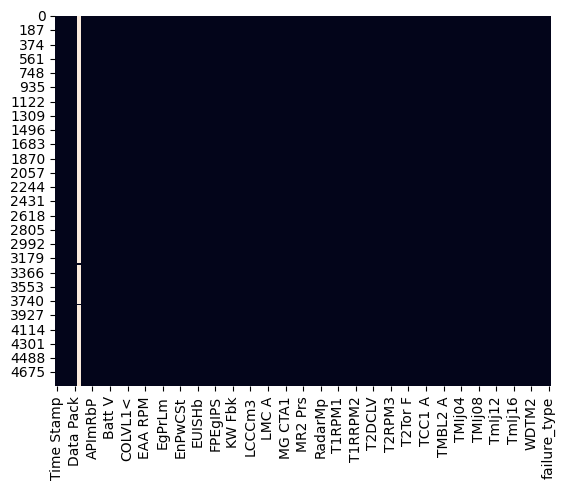

In [ ]:
sns.heatmap(df.isnull(), cbar=False)

In [ ]:
df.drop(columns=['DataPack Number'], inplace=True)

In [ ]:
df.drop(columns=['Order Number'] , inplace=True)

2. Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        col1 = df.columns[i]
        col2 = df.columns[j]
        if df[col1].equals(df[col2]):
            duplicate_cols.append((col1, col2))

for pair in duplicate_cols:
    print(f"{pair[0]} ≡ {pair[1]}")


✅ LCCCm4 ≡ LCCCm5
✅ TC1STAT ≡ TC2STAT


In [ ]:
df.drop(columns=['LCCCm5','LCCCm3','TC2STAT'], inplace=True)

In [ ]:
cols_to_drop = [
    col for col in df.columns
    if df[col].nunique(dropna=True) == 2 and (0 in df[col].unique())
]

for col in cols_to_drop:
    print(f"➔ {col}")
df = df.drop(columns=cols_to_drop)

➔ Sample  Description
➔ Data Pack
➔ EgPrLmR
➔ LCCCm4
➔ MtrsAvl


See Classes Distrbuation Before Any Preprocess Step

## **Target Variable: Class Distribution Analysis**

Before applying any preprocessing or modeling steps, we examine the distribution of the target variable `failure_type`. This feature represents the type of failure that occurred in a given engine instance, or `"no failure"` if the engine operated normally.

As shown in the distribution plot and value counts output, the dataset is **highly imbalanced**. The majority class is `'no failure'` with **4787 instances**, while the remaining failure classes are represented by only a few samples:

- `turbocharger`: 9 instances  
- `power_assembly`: 8 instances  
- `SRS_TRS`: 7 instances  
- `injector`: 7 instances  
- `0` (ambiguous/placeholder): 31 instances  

> **Note:** The `'0'` class was introduced during the merging process to serve as a **separator between engine logs**. These rows were added intentionally and do not represent real failure events.

This significant imbalance is clearly visible in the count plot, where the `'no failure'` class dominates the dataset. Such skewed class distributions must be addressed during model development to prevent the model from being biased toward the majority class.  
Appropriate techniques to handle this issue will be introduced later in the notebook.


failure_type
no failure        4787
0                   31
turbocharger         9
power_assembly       8
SRS_TRS              7
injector             7
Name: count, dtype: int64


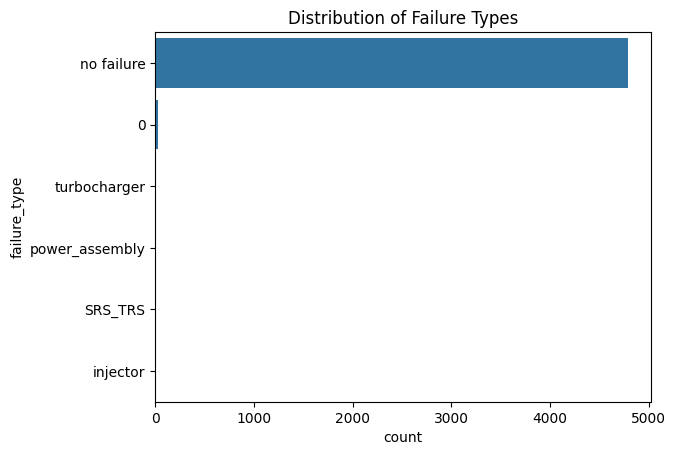

In [ ]:
print(df['failure_type'].value_counts())
sns.countplot(y='failure_type', data=df, order=df['failure_type'].value_counts().index)
plt.title("Distribution of Failure Types")
plt.show()

## Understanding and Processing Object Features


Here we want to see the features thet are object to understand them

In [ ]:
object_cols = df.select_dtypes(include='object')
object_cols.head(10)

,Time Stamp,Asset Name,COLSYST,COLVL1<,COLVL2<,EnPwCSt,Fan 1,Fan 2,LdUnit<,MG Stat,MVCC>,TC1STAT,WS Stat,failure_type
0,2024-05-10 01:38:54,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
1,2024-05-10 02:06:25,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
2,2024-05-10 06:04:02,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,OFF,EOLP,CS,no failure
3,2024-05-10 07:50:03,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,ON,EOLP,CS,no failure
4,2024-05-13 15:05:53,SAR 4005,Full,ON,ON,EOLP,FULL,OFF,OFF,TCCV,ON,EOLP,CS,no failure
5,2024-05-13 22:39:27,SAR 4005,Full,ON,ON,EOLP,HALF,OFF,OFF,TCCV,ON,EOLP,CS,no failure
6,2024-05-14 00:26:59,SAR 4005,Full,ON,ON,EOLP,OFF,FULL,OFF,TCCV,ON,EOLP,CS,no failure
7,2024-05-14 02:06:00,SAR 4005,Full,ON,ON,EOLP,FULL,OFF,OFF,TCCV,ON,EOLP,CS,no failure
8,2024-05-14 02:30:01,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,ON,EOLP,CS,no failure
9,2024-05-14 05:38:03,SAR 4005,Full,ON,ON,EOLP,FULL,FULL,OFF,TCCV,OFF,EOLP,CS,no failure


In [ ]:
object_cols = df.select_dtypes(include='object')
unique_object_counts = object_cols.apply(lambda col: col[col != "0"].nunique())
print(unique_object_counts)

Time Stamp      4806
Asset Name        22
COLSYST            5
COLVL1<            3
COLVL2<            3
EnPwCSt           10
Fan 1              4
Fan 2              4
LdUnit<            3
MG Stat            4
MVCC>              3
TC1STAT           11
WS Stat            3
failure_type       6
dtype: int64


Correlation to decide how to deals with objects

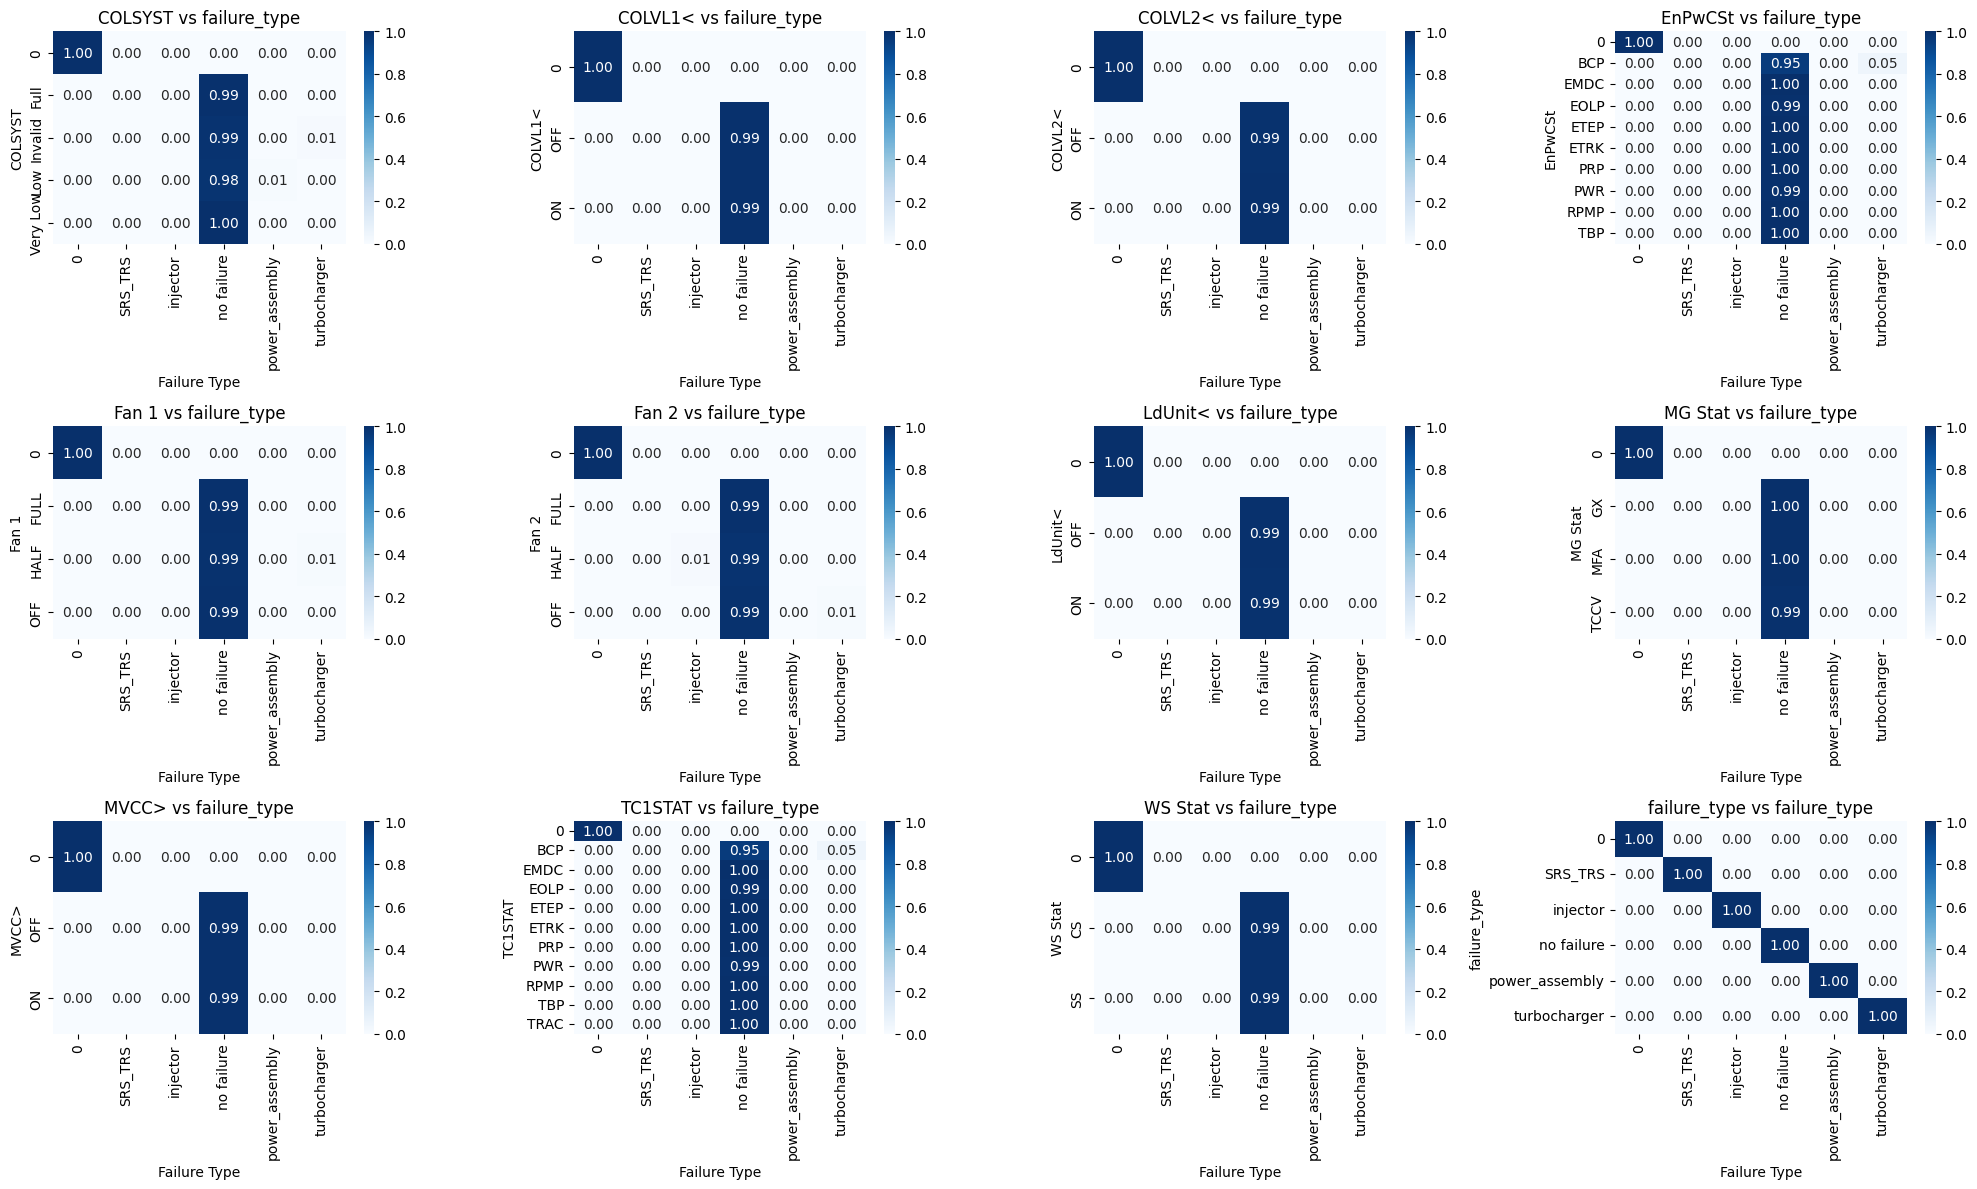

In [ ]:
exclude_cols = ['Time Stamp', 'Asset Name']
object_cols_filtered = object_cols.drop(columns=exclude_cols, errors='ignore')

n_cols = 4
n_rows = math.ceil(len(object_cols_filtered.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(object_cols_filtered.columns):
    filtered_df = df[df[col] != "0"]
    ctab = pd.crosstab(filtered_df[col], filtered_df['failure_type'], normalize='index')

    sns.heatmap(ctab, annot=True, cmap="Blues", cbar=True, fmt=".2f", ax=axes[idx])
    axes[idx].set_title(f"{col} vs failure_type")
    axes[idx].set_xlabel("Failure Type")
    axes[idx].set_ylabel(col)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Understanding and Processing Categorical (Object) Features**

In this step, we analyze the object-type (categorical) features present in the dataset. These features typically include status indicators, sensor modes, or device configurations recorded as text.

### Step 1: Overview of Object Features
We begin by listing all columns with `object` data types and previewing a few rows to understand their nature. Features such as `Fan 1`, `EDUP`, `MG Stat`, and others contain state values like `"ON"`, `"OFF"`, or categorical indicators such as `"FULL"`, `"CS"`, etc.

We also compute the unique value counts for each object column. This helps us identify:
- Features with a large number of unique values (possibly IDs or non-informative).
- Features with low variation (e.g., one dominant category across rows).

### Step 2: Feature Selection Based on Correlation

To determine which categorical features are informative for predicting failure, we examine their relationship with the `failure_type` column using **heatmaps of normalized crosstabulations**. This visual method helps detect features that have distinct distributions across different failure classes.

From this analysis, we drop features that show no useful variation or weak/no correlation with the target. Examples of dropped features include:
- `COLSV1`, `COLSV2`, `MG Stat`, `TC1STAT`, etc.

These features were either redundant, irrelevant, or uniformly distributed across all rows (i.e., having no predictive power).

### Step 3: Result

After this filtering step, the dataset retains only the most relevant object features, and the remaining features are either numeric or structured for encoding.


In [ ]:
cols_to_drop = [
    'Sample Description', 'Data Pack', 'COLSYST', 'COLVL1<', 'COLVL2<',
    'EnPwCSt', 'Fan 1', 'Fan 2', 'LdUnit<', 'MG Stat', 'MVCC>',
    'TC1STAT', 'TC2STAT', 'WS Stat'
]

df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore', inplace=True)

Data After Dropped Features (Objects)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Data columns (total 92 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time Stamp    4849 non-null   object 
 1   Asset Name    4849 non-null   object 
 2   AmbTmpF       4849 non-null   float64
 3   APCcLb        4849 non-null   float64
 4   APImRbP       4849 non-null   float64
 5   ATImRbF       4849 non-null   float64
 6   AWTF          4849 non-null   float64
 7   Bar Prs       4849 non-null   float64
 8   Batt V        4849 non-null   float64
 9   CA V          4849 non-null   float64
 10  ChpDty        4849 non-null   float64
 11  DCL1V         4849 non-null   int64  
 12  DCL2V         4849 non-null   int64  
 13  EAA RPM       4849 non-null   int64  
 14  EEngRPM       4849 non-null   int64  
 15  EgAirTF       4849 non-null   float64
 16  EgOilTF       4849 non-null   float64
 17  EgPrLm        4849 non-null   int64  
 18  Eng RPM       4849 non-null 

## **Understanding and Processing Numerical Features**

The dataset contains a large number of numerical features derived from sensor readings. To ensure model reliability and efficiency, we perform a detailed analysis and reduction of these features.

### Step 1: Correlation Analysis

We begin by generating a Pearson correlation matrix between all numerical features. The heatmap below visualizes these relationships, highlighting strongly correlated pairs.

- High correlation values (close to 1 or -1) between features indicate potential redundancy.
- Strongly correlated features may introduce multicollinearity, affecting model interpretability and performance.

### Step 2: Removing Highly Correlated Features

To address redundancy, we remove one feature from each pair whose correlation exceeds a defined threshold (**0.99** in our case). This process helps:
- Eliminate duplicate signals.
- Simplify the feature space.
- Improve generalization during model training.

As a result, the feature set is reduced from **113 to 65 features**, keeping only the most informative variables.

### Step 3: Summary of Cleaned Data

After dropping redundant features, we display the updated data structure using `df.info()` to verify the column count and datatypes.


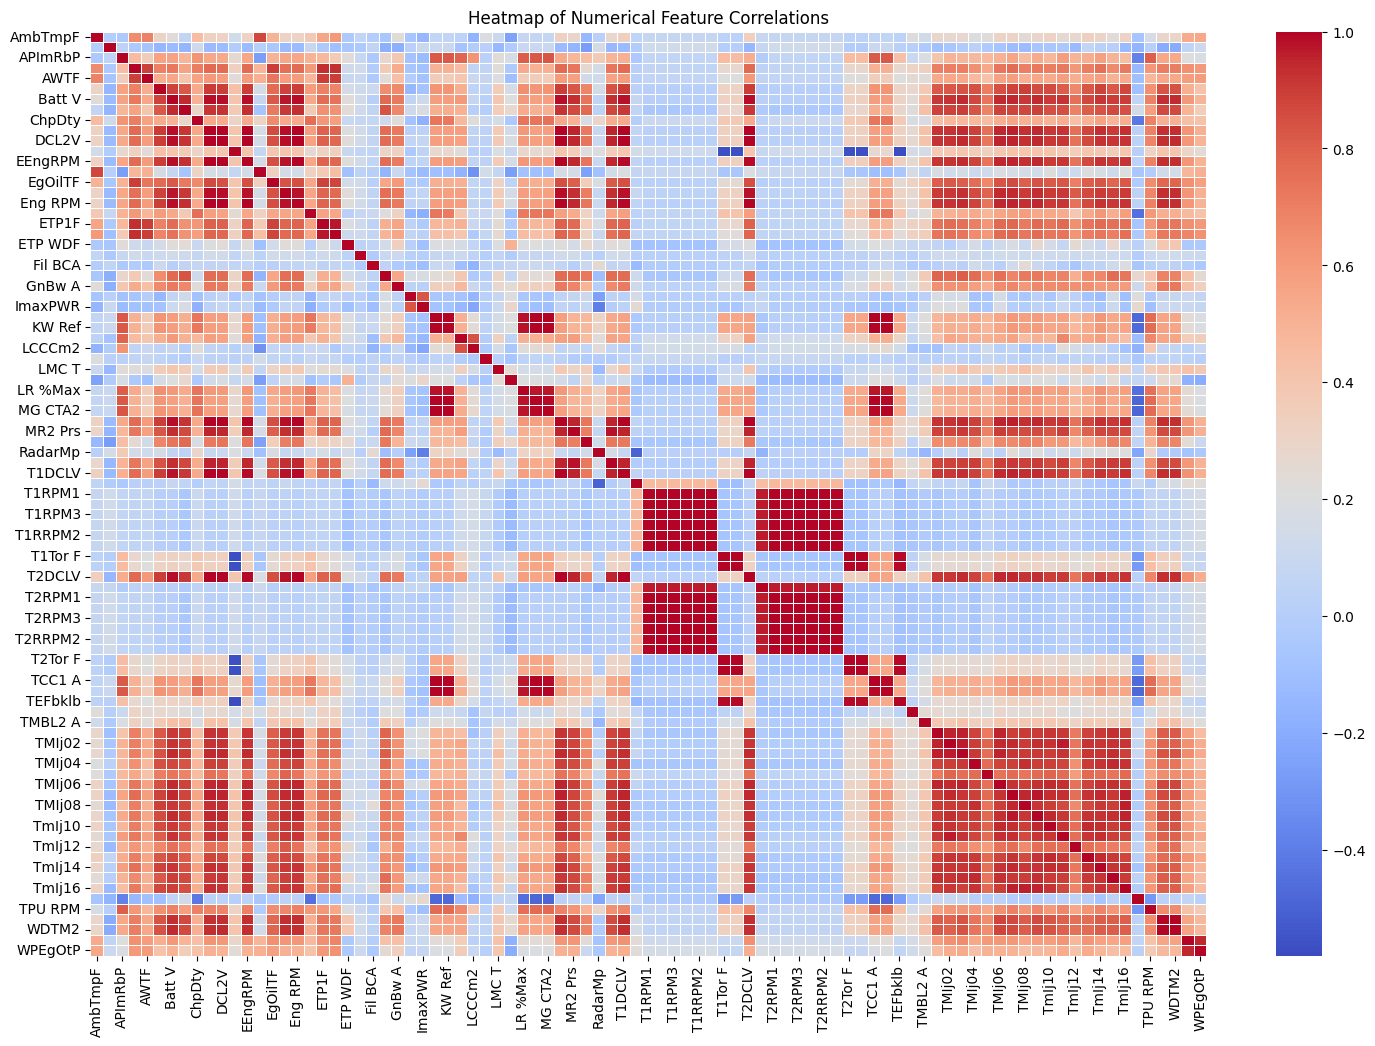

In [ ]:
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap of Numerical Feature Correlations")
plt.show()


In [ ]:
threshold = 0.99
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
print(to_drop)
df = df.drop(columns=to_drop)


['DCL2V', 'EEngRPM', 'Eng RPM', 'KW Ref', 'MG CTA1', 'MG CTA2', 'MG V', 'T1DCLV', 'T1RPM2', 'T1RPM3', 'T1RRPM1', 'T1RRPM2', 'T1RRPM3', 'T1Tor R', 'T2DCLV', 'T2RPM1', 'T2RPM2', 'T2RPM3', 'T2RRPM1', 'T2RRPM2', 'T2RRPM3', 'T2Tor F', 'T2Tor R', 'TCC1 A', 'TCC2 A', 'TEFbklb', 'WDTM2']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4849 entries, 0 to 4848
Data columns (total 65 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time Stamp    4849 non-null   object 
 1   Asset Name    4849 non-null   object 
 2   AmbTmpF       4849 non-null   float64
 3   APCcLb        4849 non-null   float64
 4   APImRbP       4849 non-null   float64
 5   ATImRbF       4849 non-null   float64
 6   AWTF          4849 non-null   float64
 7   Bar Prs       4849 non-null   float64
 8   Batt V        4849 non-null   float64
 9   CA V          4849 non-null   float64
 10  ChpDty        4849 non-null   float64
 11  DCL1V         4849 non-null   int64  
 12  EAA RPM       4849 non-null   int64  
 13  EgAirTF       4849 non-null   float64
 14  EgOilTF       4849 non-null   float64
 15  EgPrLm        4849 non-null   int64  
 16  EngineR       4849 non-null   float64
 17  ETP1F         4849 non-null   float64
 18  ETP2F         4849 non-null 

### Remaining Object Features After Cleaning

Following the removal of redundant and irrelevant columns, we examined the remaining categorical or string-based (`object`) features.

Currently, only **3 object-type columns** remain in the dataset:
- `Time Stamp`: A timestamp column indicating when each record was collected.
- `Asset Name`: The identifier or name of the engine unit.
- `failure_type`: The target variable indicating the failure category.

These columns will either be transformed (e.g., label encoding for `failure_type`) or excluded from numerical modeling if not suitable.


In [ ]:
object_columns = df.select_dtypes(include='object').columns.tolist()

print(f"(object): {len(object_columns)}")

print(object_columns)

(object): 3
['Time Stamp', 'Asset Name', 'failure_type']


## **Preprocessing and Visualization of Sensor Data**

In this phase, we focus on preparing the sensor readings for downstream modeling. Sensor data is high-dimensional, noisy, and collected across multiple engine units with timestamps.

### Step 1: Segmentation by Engine

Using known boundaries, we segment the dataset into separate engine instances. This allows us to analyze each engine's operational timeline independently.

### Step 2: Standardization

To ensure consistency across sensors with different units or scales, we apply **standardization** using `StandardScaler`. This transformation centers each sensor’s values around zero with unit variance.

### Step 3: Outlier Detection with Hampel Filter

To further improve signal quality, we apply a **Hampel Filter**, which removes short-term outliers in the signal. This helps:
- Highlight the general trend of each sensor.
- Prevent spikes or noise from misleading the model.

### Step 4: Visualization

We plot both the **original** and **smoothed (filtered)** sensor signals:
- Comparison plots show how the Hampel filter improves signal stability.
- This step is useful for verifying the filtering logic and selecting the most stable sensors.

### Step 5: Final Time Alignment and Export

We ensure the `Time Stamp` column is properly parsed into datetime format. Finally, the cleaned and standardized sensor readings, along with their labels and timestamps, are exported for use in the modeling stage.


<ipython-input-23-44efee835825>:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


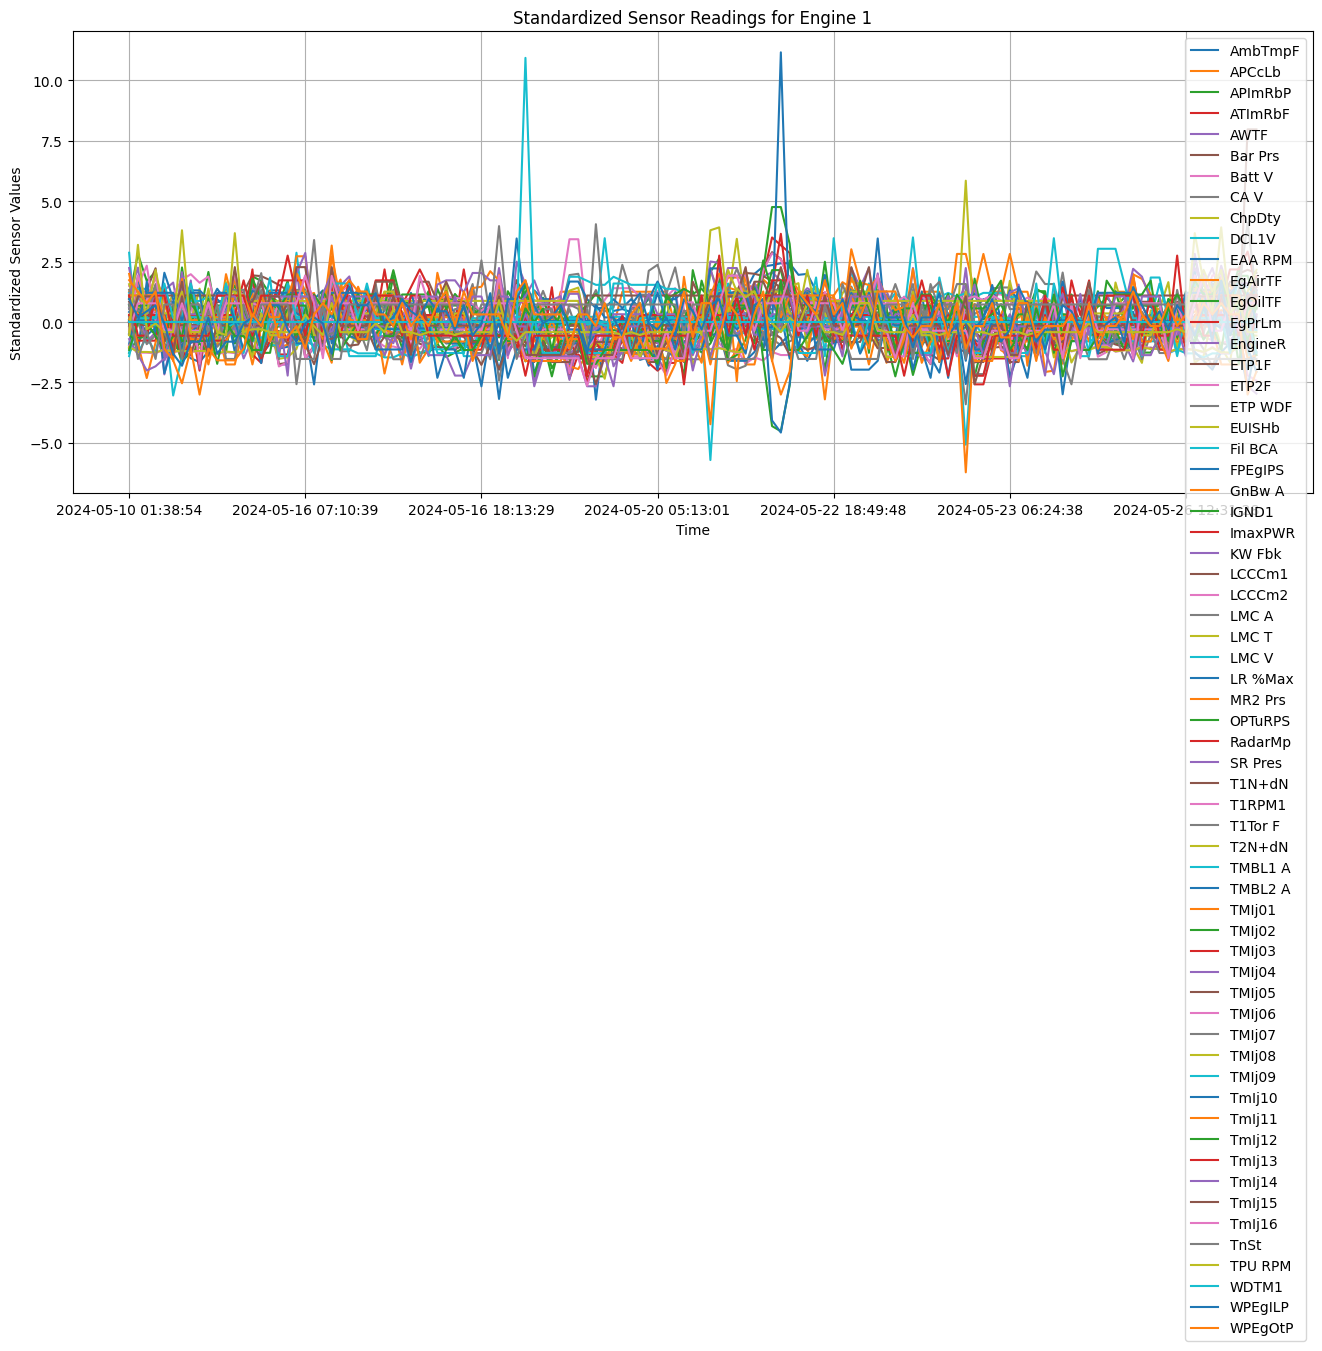

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
zero_rows = df[numeric_cols].eq(0).all(axis=1)
zero_indices = df[zero_rows].index.to_list()
boundaries = [0] + zero_indices + [len(df)]

engine_idx = 0
start, end = boundaries[engine_idx], boundaries[engine_idx + 1]

engine_df = df.iloc[start:end].dropna(how='all').copy()

engine_df = engine_df.set_index('Time Stamp') if 'Time Stamp' in engine_df.columns else engine_df

sensor_cols = engine_df.select_dtypes(include='number').columns

scaler = StandardScaler()
engine_df_scaled = pd.DataFrame(scaler.fit_transform(engine_df[sensor_cols]),
                                 columns=sensor_cols, index=engine_df.index)

engine_df_scaled.plot(figsize=(16, 6), title=f"Standardized Sensor Readings for Engine {engine_idx + 1}")
plt.xlabel("Time")
plt.ylabel("Standardized Sensor Values")
plt.grid(True)
plt.tight_layout()
plt.show()


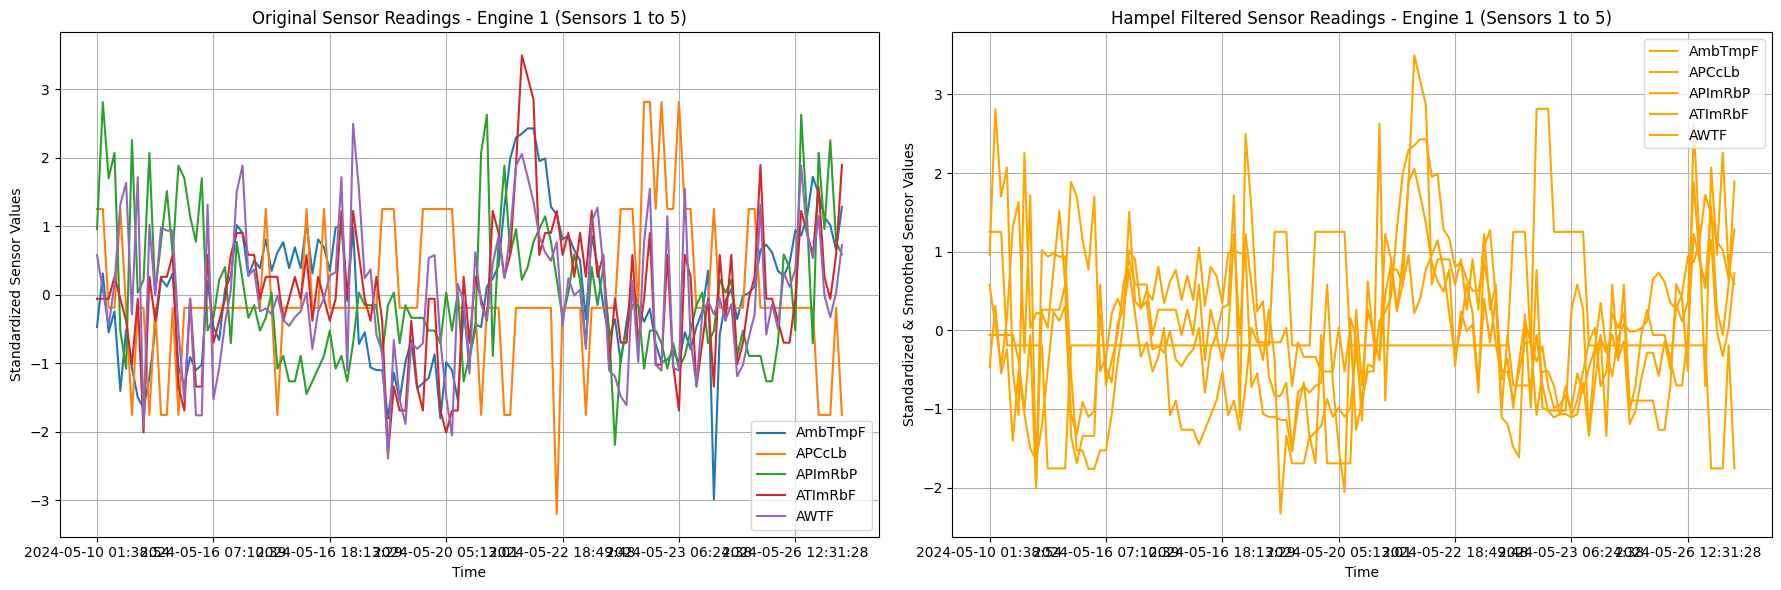

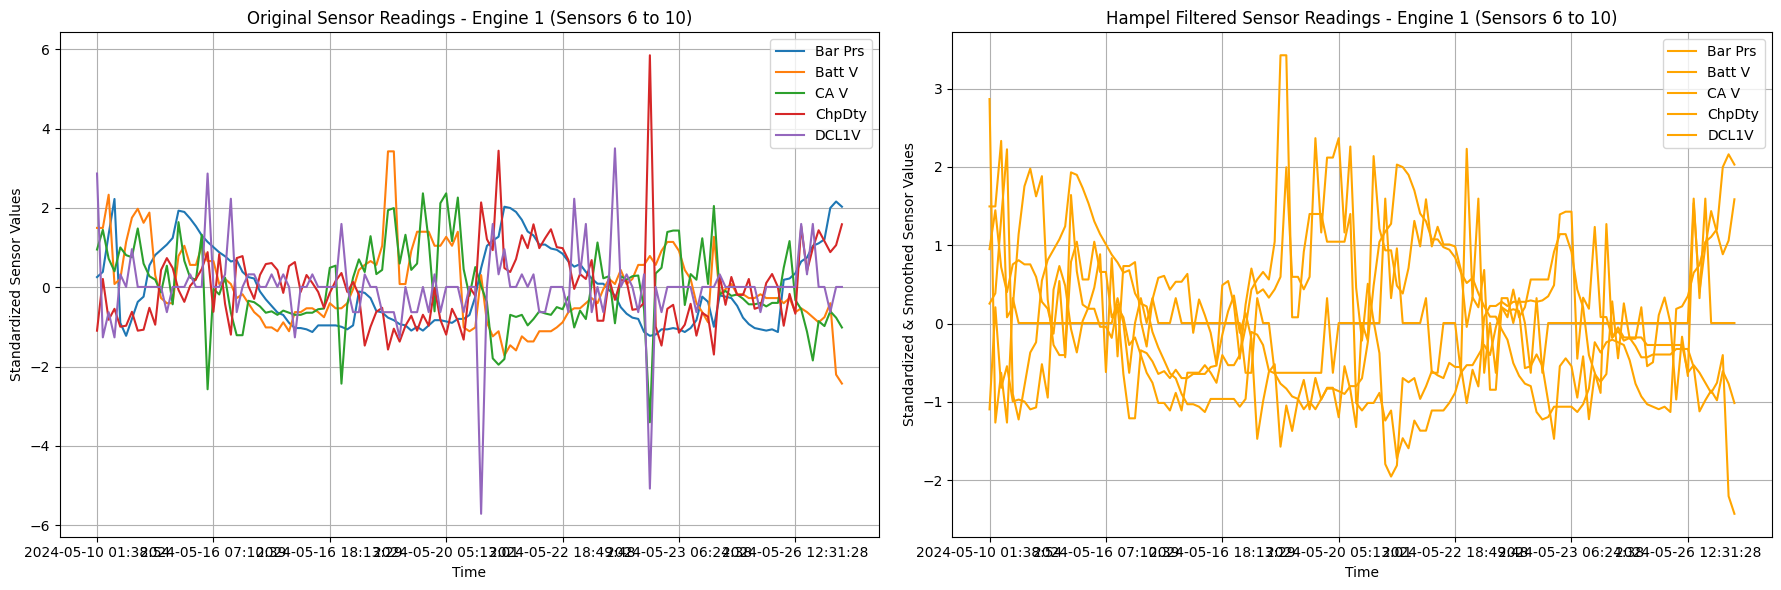

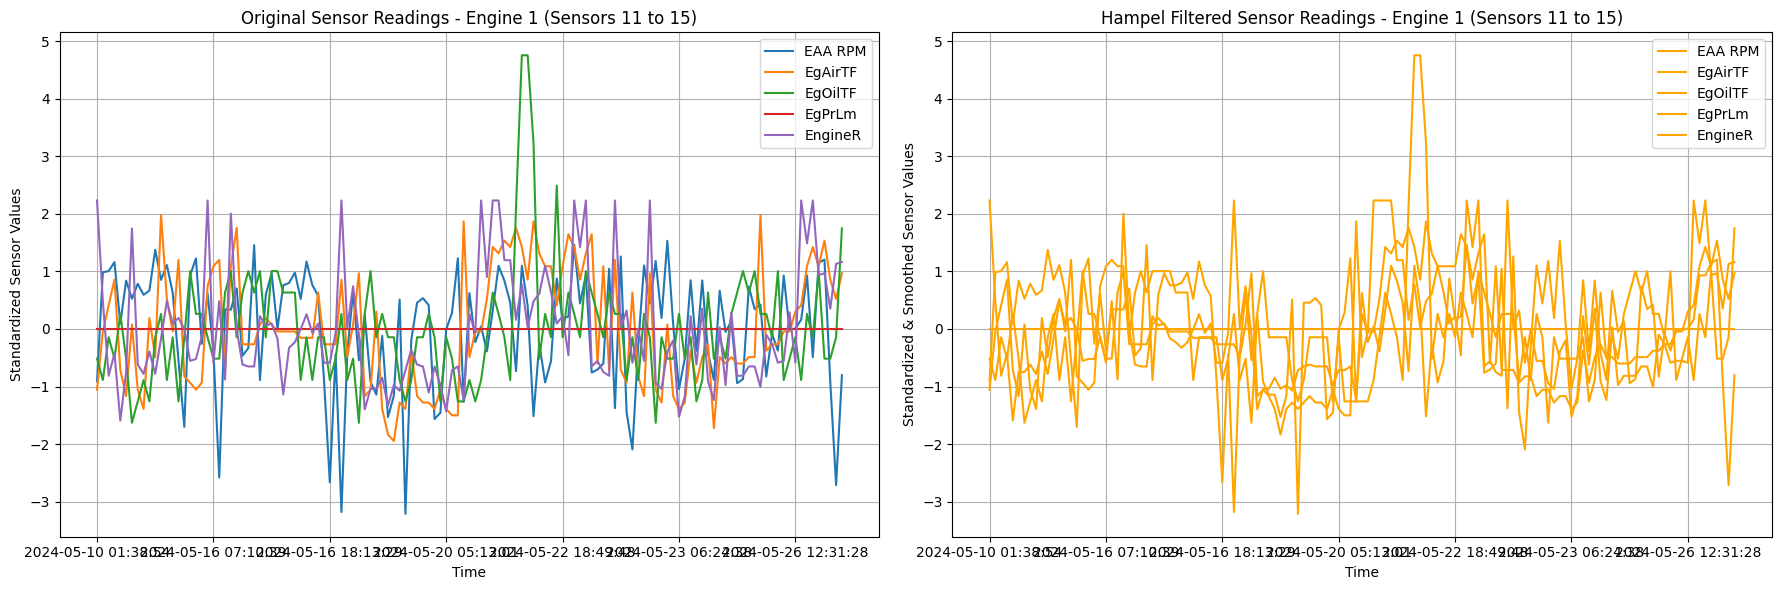

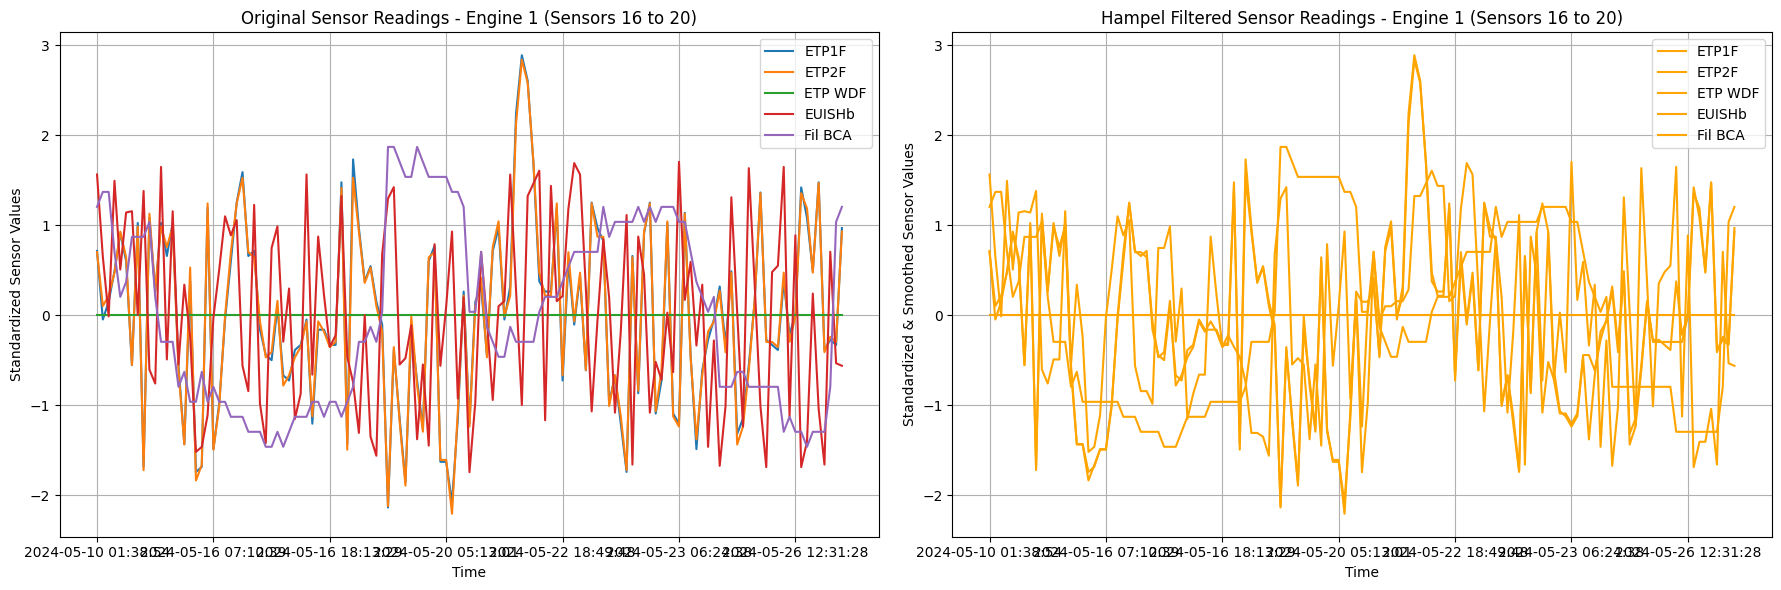

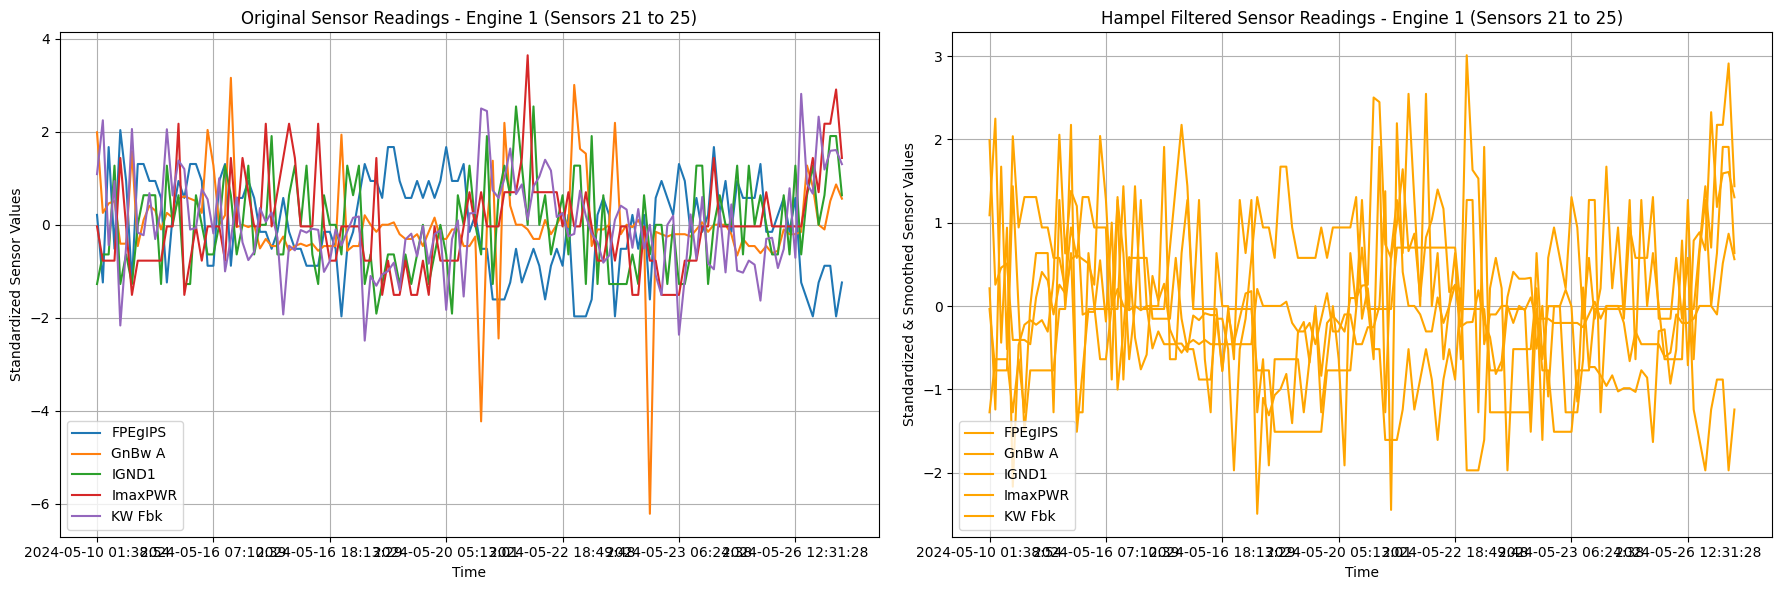

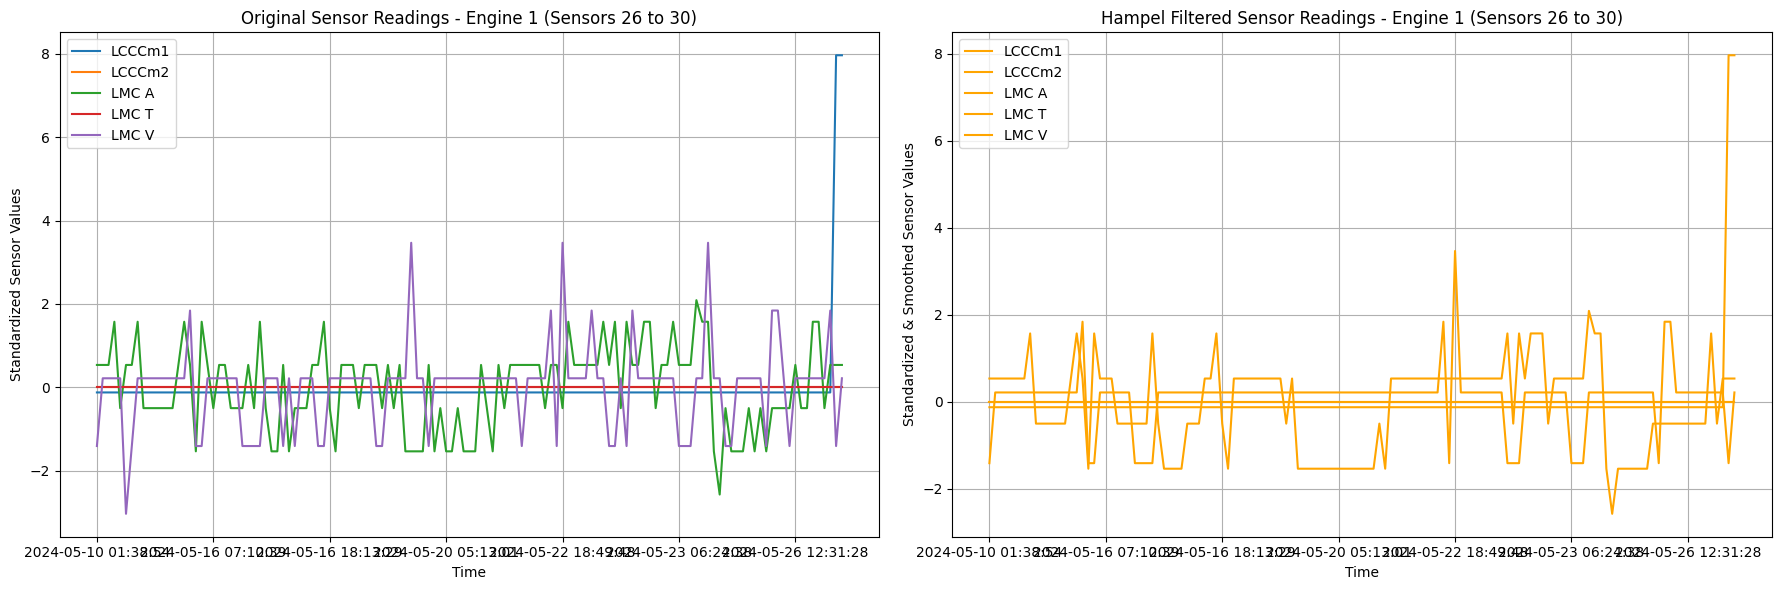

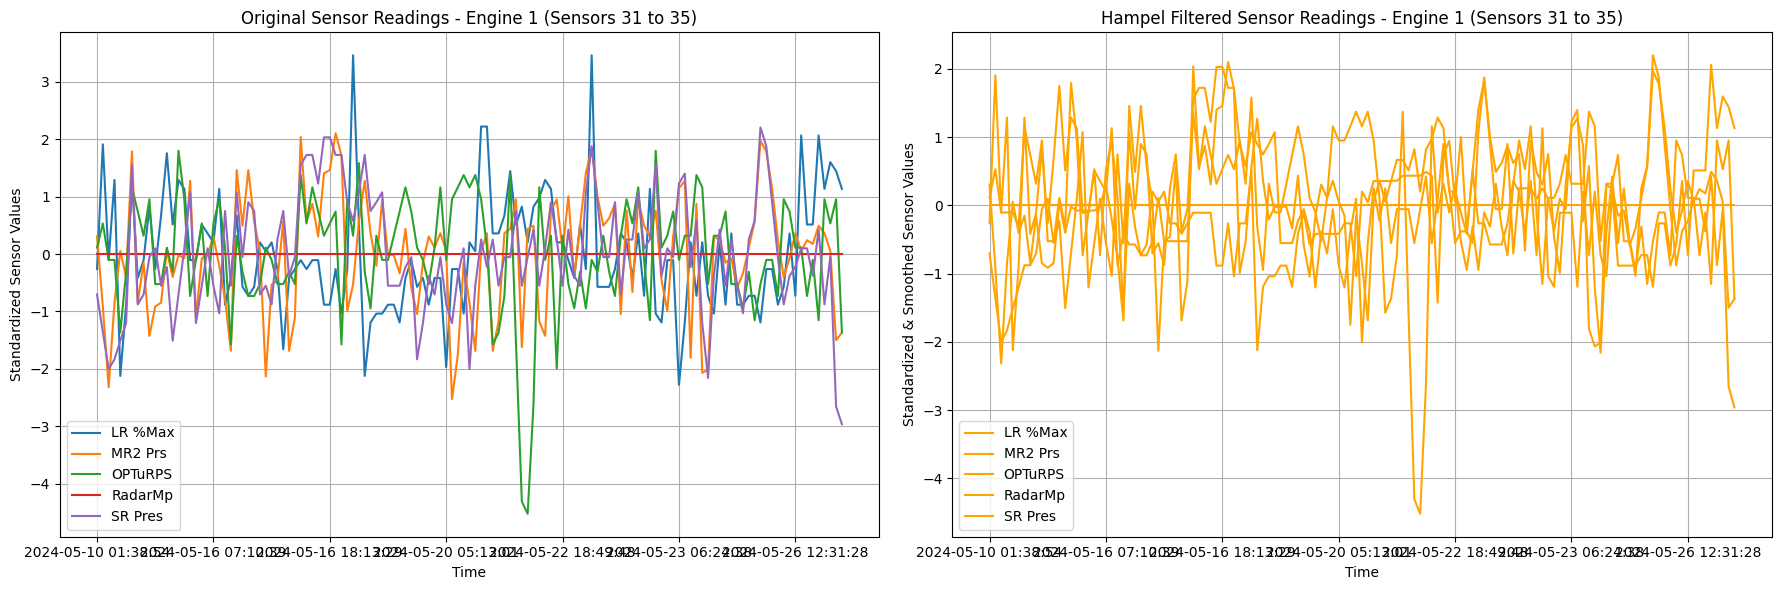

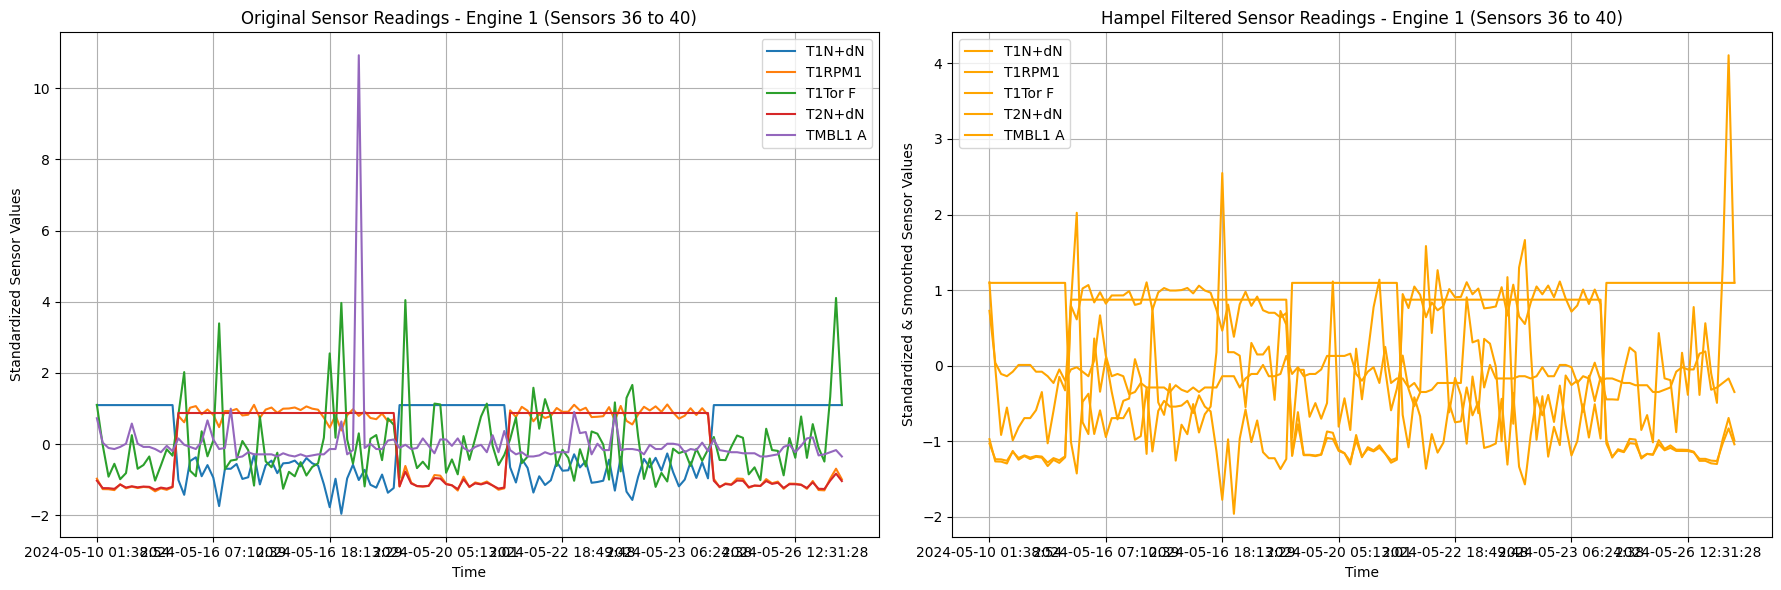

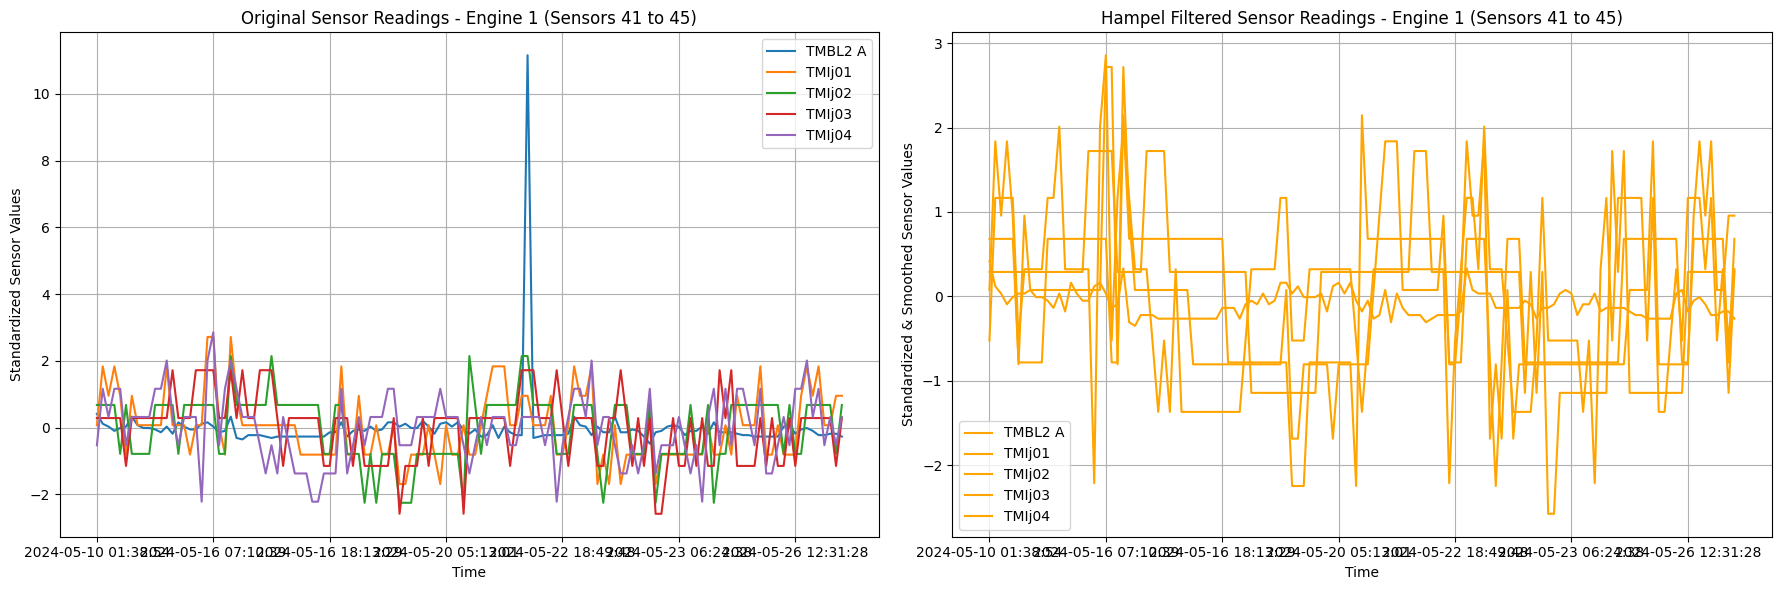

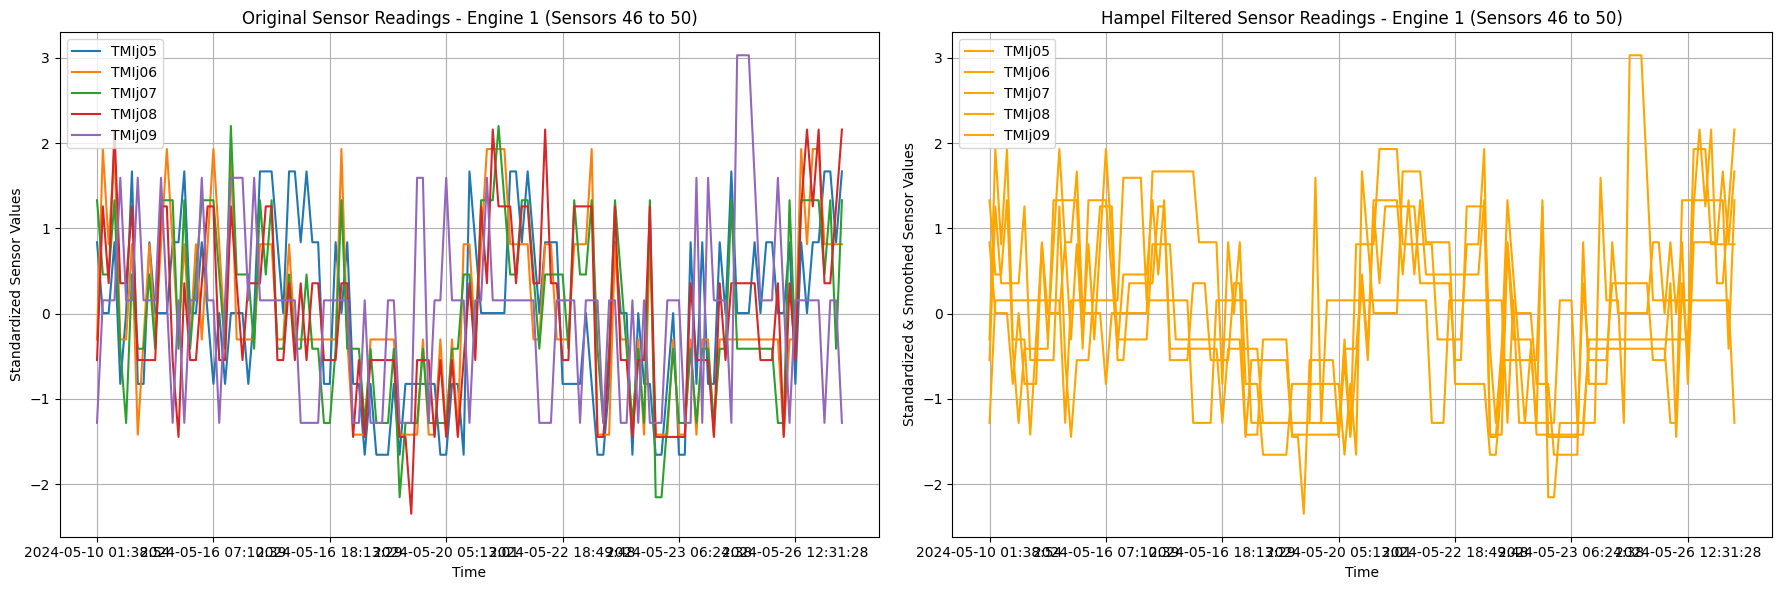

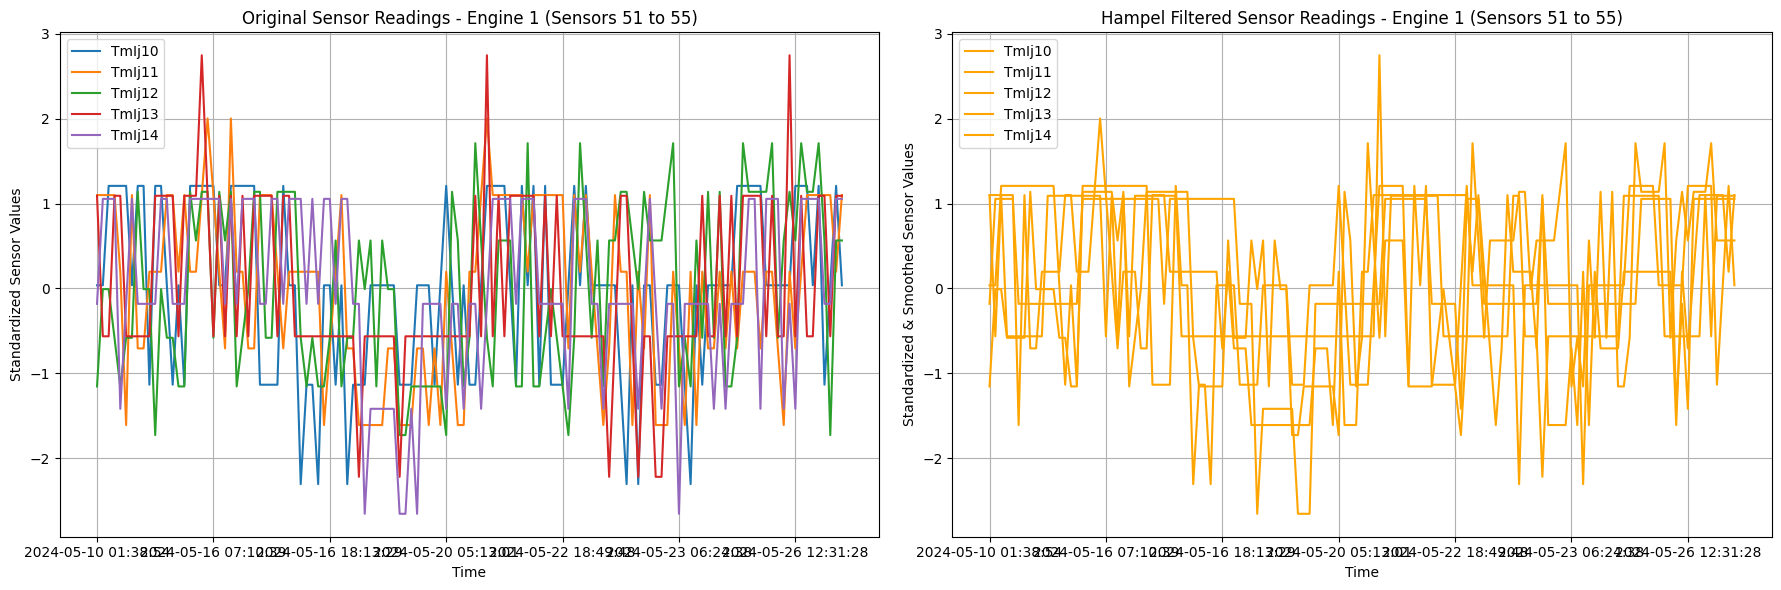

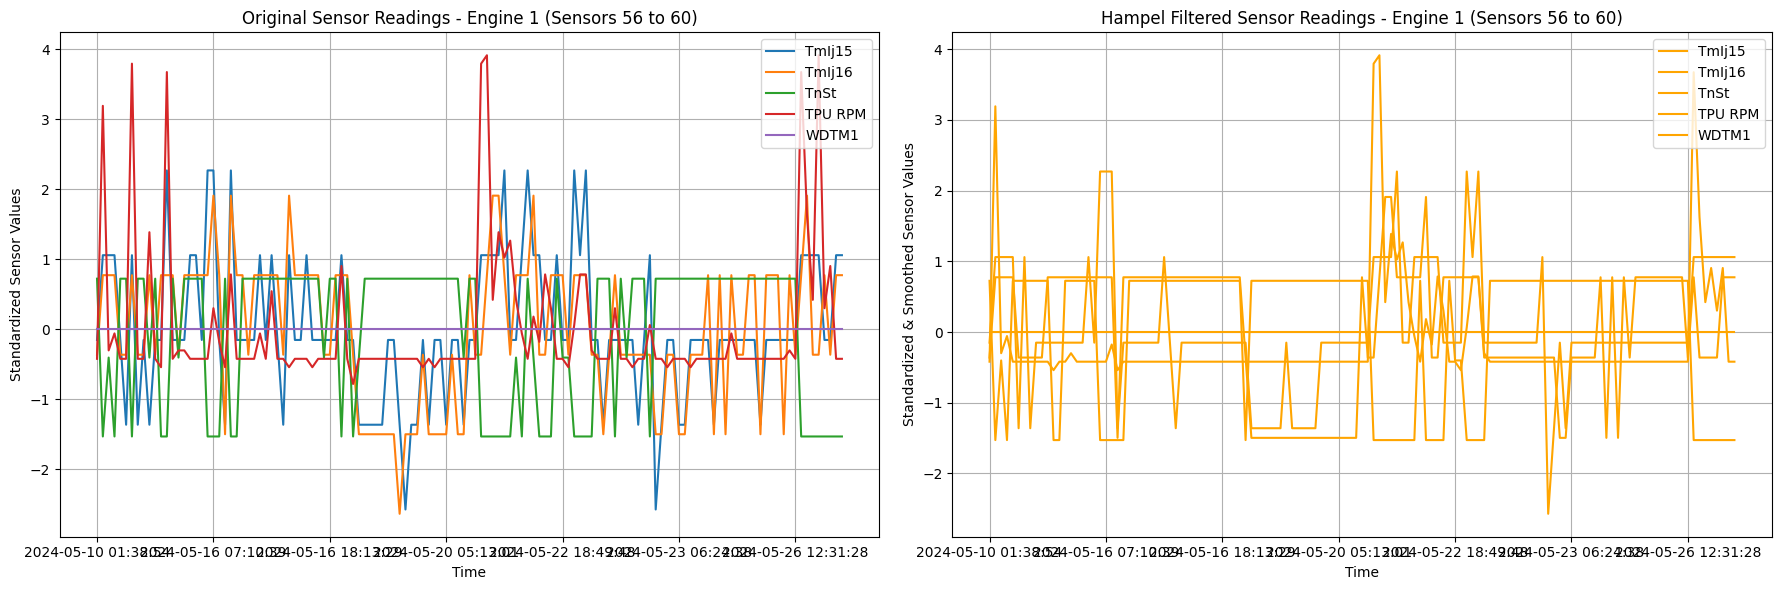

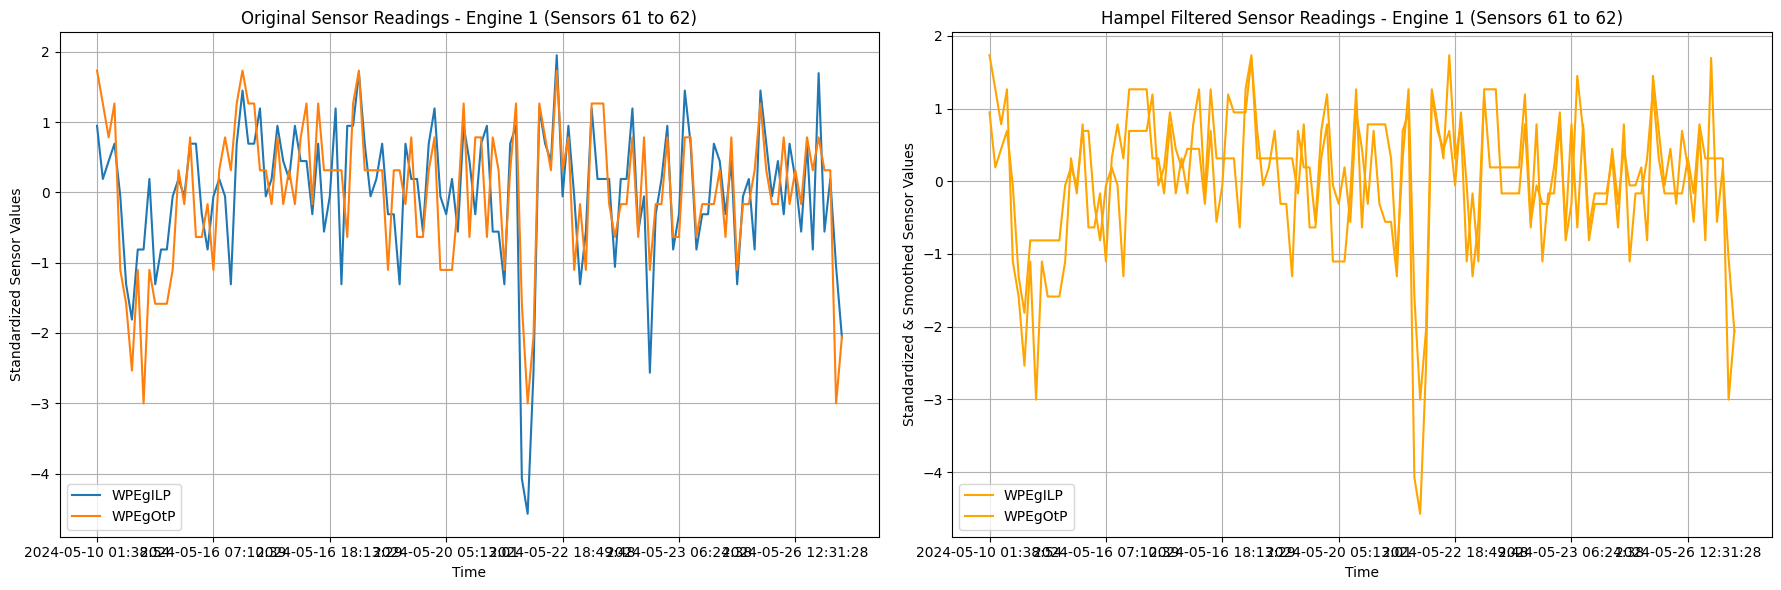

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
zero_rows = df[numeric_cols].eq(0).all(axis=1)
zero_indices = df[zero_rows].index.to_list()
boundaries = [0] + zero_indices + [len(df)]

engine_idx = 0
start, end = boundaries[engine_idx], boundaries[engine_idx + 1]

engine_df = df.iloc[start:end].dropna(how='all').copy()

engine_df = engine_df.set_index('Time Stamp') if 'Time Stamp' in engine_df.columns else engine_df

sensor_cols = engine_df.select_dtypes(include='number').columns

scaler = StandardScaler()
engine_df_scaled = pd.DataFrame(scaler.fit_transform(engine_df[sensor_cols]),
                                 columns=sensor_cols, index=engine_df.index)

def hampel_filter(series, window_size=5, n_sigmas=3):
    k = 1.4826
    rolling_median = series.rolling(window=window_size, center=True).median()
    mad = k * (series.rolling(window=window_size, center=True)
                   .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True))
    diff = np.abs(series - rolling_median)
    outlier_idx = diff > (n_sigmas * mad)
    filtered_series = series.copy()
    filtered_series[outlier_idx] = rolling_median[outlier_idx]
    return filtered_series

engine_df_smoothed = engine_df_scaled.apply(lambda col: hampel_filter(col))

step = 5
for i in range(0, len(sensor_cols), step):
    cols_slice = sensor_cols[i:i+step]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    engine_df_scaled[cols_slice].plot(ax=axes[0], title=f"Original Sensor Readings - Engine {engine_idx + 1} (Sensors {i+1} to {i+len(cols_slice)})")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Standardized Sensor Values")
    axes[0].grid(True)

    engine_df_smoothed[cols_slice].plot(ax=axes[1], title=f"Hampel Filtered Sensor Readings - Engine {engine_idx + 1} (Sensors {i+1} to {i+len(cols_slice)})", color='orange')
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Standardized & Smoothed Sensor Values")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
numerical_cols = df.select_dtypes(include='number').columns
df_numeric = df[numerical_cols].copy()

def hampel_filter(series, window_size=5, n_sigmas=3):
    k = 1.4826
    new_series = series.copy()
    rolling_median = series.rolling(window=window_size, center=True).median()
    mad = k * (series.rolling(window=window_size, center=True)
                      .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True))
    difference = np.abs(series - rolling_median)
    outlier_idx = difference > (n_sigmas * mad)
    new_series[outlier_idx] = rolling_median[outlier_idx]
    return new_series


mask_real_data = ~(df['Asset Name'] == 0)

df_numeric_filtered = df_numeric[mask_real_data]

filtered_numeric_df_real = df_numeric_filtered.apply(lambda col: hampel_filter(col))

filtered_numeric_df = df_numeric.copy()
filtered_numeric_df.loc[mask_real_data] = filtered_numeric_df_real

df_filtered = pd.concat([filtered_numeric_df, df.drop(columns=numerical_cols)], axis=1)



In [ ]:
def standardize_real_data(df, asset_col='Asset Name'):

    numerical_cols = df.select_dtypes(include='number').columns
    numeric_data = df[numerical_cols]

    mask_real_data = ~(df[asset_col] == 0)

    scaler = StandardScaler()
    scaled_array_real = scaler.fit_transform(numeric_data[mask_real_data])

    scaled_df_real = pd.DataFrame(scaled_array_real, columns=numerical_cols, index=numeric_data[mask_real_data].index)

    scaled_df = numeric_data.copy()
    scaled_df.loc[mask_real_data] = scaled_df_real

    df_standardized = pd.concat([scaled_df, df.drop(columns=numerical_cols)], axis=1)
    return df_standardized

In [ ]:
df_standardized=standardize_real_data(df_filtered)
df_standardized['Time Stamp'] = pd.to_datetime(
    df_standardized['Time Stamp'],
    infer_datetime_format=True,
    errors='coerce'
)

print(df_standardized['Time Stamp'].head(10))
print("(NaT):", df_standardized['Time Stamp'].isna().sum())


0   2024-05-10 01:38:54
1   2024-05-10 02:06:25
2   2024-05-10 06:04:02
3   2024-05-10 07:50:03
4   2024-05-13 15:05:53
5   2024-05-13 22:39:27
6   2024-05-14 00:26:59
7   2024-05-14 02:06:00
8   2024-05-14 02:30:01
9   2024-05-14 05:38:03
Name: Time Stamp, dtype: datetime64[ns]
(NaT): 31


<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 2.2553906   0.8565973   1.07179627 ... -0.86499444 -0.86499444
 -1.29539238]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.04563645  0.59815489  0.61579845 ...  1.76262961  2.11550074
  0.28351147]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.14998585 0.14998585 0.14998585 ... 0.14998585 0.14998585 0.14998585]' 

In [ ]:
print(df_standardized['Time Stamp'].dtype)

datetime64[ns]


In [ ]:
df_standardized.to_csv("df_standardized.csv", index=False)

In [ ]:
df_standardized.head(10)

,AmbTmpF,APCcLb,APImRbP,ATImRbF,AWTF,Bar Prs,Batt V,CA V,ChpDty,DCL1V,...,TmIj15,TmIj16,TnSt,TPU RPM,WDTM1,WPEgILP,WPEgOtP,Time Stamp,Asset Name,failure_type
0,0.080447,-0.764641,-1.800280,-0.359353,0.326135,-0.940371,0.669579,1.113948,-2.126988,2.255391,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.848351,0.774408,2024-05-10 01:38:54,SAR 4005,no failure
1,0.534072,-0.764641,-1.265346,-0.359353,-0.037737,-0.839725,0.669579,1.533474,-1.043336,0.856597,...,-0.884107,-0.946040,-0.300412,-1.145500,0.432396,0.582323,0.645384,2024-05-10 02:06:25,SAR 4005,no failure
2,0.036191,-0.764641,-1.586182,-0.359353,-0.416770,-0.110722,0.952450,0.919168,-1.897754,1.071796,...,-0.884107,-0.946040,1.318589,-1.826379,0.432396,0.671851,0.512564,2024-05-10 06:04:02,SAR 4005,no failure
3,0.213215,-1.014973,-1.479444,-0.359353,0.022909,0.569319,0.190875,0.649472,-1.668520,0.856597,...,-0.884107,-0.946040,-0.300412,-1.779008,0.432396,0.758822,0.645384,2024-05-10 07:50:03,SAR 4005,no failure
4,-0.461689,-1.014973,-2.228166,-0.359353,0.856782,-1.824423,0.234393,0.949134,-2.043630,1.394595,...,-0.884107,-0.946040,2.937590,-1.849749,0.432396,0.495352,-0.007329,2024-05-13 15:05:53,SAR 4005,no failure
5,0.058319,-1.014973,-2.388584,-0.597160,1.084202,-2.074678,0.549903,0.994083,-2.022791,1.286995,...,-1.290967,-1.169912,2.937590,-1.849749,0.432396,0.055382,-0.140148,2024-05-13 22:39:27,SAR 4005,no failure
6,-0.262537,-1.014973,-1.425764,-1.072773,-0.295479,-1.748259,0.756616,0.949134,-2.043630,1.286995,...,-0.884107,-1.169912,2.937590,-1.849749,0.432396,-0.121118,-0.401992,2024-05-14 00:26:59,SAR 4005,no failure
7,-0.517009,-1.014973,-2.067747,-0.359353,1.144847,-1.419119,0.832774,0.949134,-2.126988,1.286995,...,-1.290967,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.007329,2024-05-14 02:06:00,SAR 4005,no failure
8,-0.605521,-1.014973,-2.014068,-1.807812,-1.478063,-1.318473,0.713097,0.814286,-2.106149,1.286995,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.531017,2024-05-14 02:30:01,SAR 4005,no failure
9,-0.351049,-1.014973,-2.014068,-0.121546,0.644523,-0.714597,0.800135,0.544591,-1.647680,1.286995,...,-1.087537,-1.169912,2.937590,-1.849749,0.432396,0.229323,-0.007329,2024-05-14 05:38:03,SAR 4005,no failure


## **Sliding Window Creation and Class Balancing**

After cleaning and transforming the time-series sensor data, we prepare the dataset for training by performing the following key steps:

### Step 1: Sliding Window Generation

To convert the time-series data into a supervised learning format, we apply a sliding window approach:
- Each window captures a sequence of sensor readings over a fixed time frame (`window_size=30`).
- A stride is used to control overlap between windows.
- Each window is labeled based on whether it contains failure events (`multi_class=True` for classification by failure type).

### Step 2: Oversampling to Balance Class Distribution

Due to the high imbalance in the raw dataset, we apply oversampling to ensure each class has the same number of training samples:
- Rare failure classes (e.g., `turbocharger`, `injector`) are duplicated.
- The `Resample` function is used to expand underrepresented classes to match the majority.

This results in a **fully balanced dataset** across all five classes:
- `0`: No failure  
- `1`: Turbocharger  
- `2`: Power Assembly  
- `3`: SRS_TRS  
- `4`: Injector  

Each class ends up with the same number of examples (e.g., **3941 samples per class**), as shown in the histogram and value counts.

### Benefit:
This step is essential to prevent model bias toward the majority class and ensure fair training across all failure categories.


In [ ]:
df_standardized['Time Stamp'] = pd.to_datetime(df_standardized['Time Stamp'], errors='coerce')
df_sorted = df_standardized.sort_values(['Asset Name', 'Time Stamp']).reset_index(drop=True)

In [ ]:
def create_sliding_windows_with_oversampling(df, window_size=30, stride=1, target_col='failure_type', asset_col='Asset Name', multi_class=False):
    import numpy as np
    import pandas as pd
    from sklearn.utils import shuffle, resample

    sensor_cols = df.select_dtypes(include='number').columns.drop(target_col)

    X_windows, y_windows = [], []

    for asset in df[asset_col].unique():
        asset_df = df[df[asset_col] == asset]
        X_full = asset_df[sensor_cols].values
        y_full = asset_df[target_col].values

        for start in range(0, len(X_full) - window_size + 1, stride):
            end = start + window_size
            window_X = X_full[start:end]
            window_y = y_full[start:end]

            if window_X.shape[0] == window_size:
                if multi_class:
                    failures_in_window = window_y[window_y != 0]
                    label = failures_in_window[0] if len(failures_in_window) > 0 else 0
                else:
                    label = 1 if np.any(window_y == 1) else 0

                X_windows.append(window_X)
                y_windows.append(label)

    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)

    # Oversampling
    if multi_class:
        df_win = pd.DataFrame({'X': list(X_windows), 'y': y_windows})
        max_class = df_win['y'].value_counts().max()

        oversampled = []
        for label in df_win['y'].unique():
            subset = df_win[df_win['y'] == label]
            if len(subset) < max_class:
                subset_upsampled = resample(subset, replace=True, n_samples=max_class, random_state=42)
            else:
                subset_upsampled = subset
            oversampled.append(subset_upsampled)

        df_balanced = pd.concat(oversampled)
        X_balanced = np.stack(df_balanced['X'].values)
        y_balanced = df_balanced['y'].values

    else:
        X_failure = X_windows[y_windows == 1]
        y_failure = y_windows[y_windows == 1]
        X_normal = X_windows[y_windows == 0]
        y_normal = y_windows[y_windows == 0]

        n_samples_needed = len(X_normal) - len(X_failure)
        repeats = (n_samples_needed // len(X_failure)) + 1

        X_failure_oversampled = np.repeat(X_failure, repeats, axis=0)[:n_samples_needed]
        y_failure_oversampled = np.repeat(y_failure, repeats, axis=0)[:n_samples_needed]

        X_balanced = np.concatenate([X_normal, X_failure, X_failure_oversampled], axis=0)
        y_balanced = np.concatenate([y_normal, y_failure, y_failure_oversampled], axis=0)

    return shuffle(X_balanced, y_balanced, random_state=42)


<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 2.2553906   0.8565973   1.07179627 ... -0.86499444 -0.86499444
 -1.29539238]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.04563645  0.59815489  0.61579845 ...  1.76262961  2.11550074
  0.28351147]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_df.loc[mask_real_data] = scaled_df_real
<ipython-input-26-dcb1194152a1>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.14998585 0.14998585 0.14998585 ... 0.14998585 0.14998585 0.14998585]' 

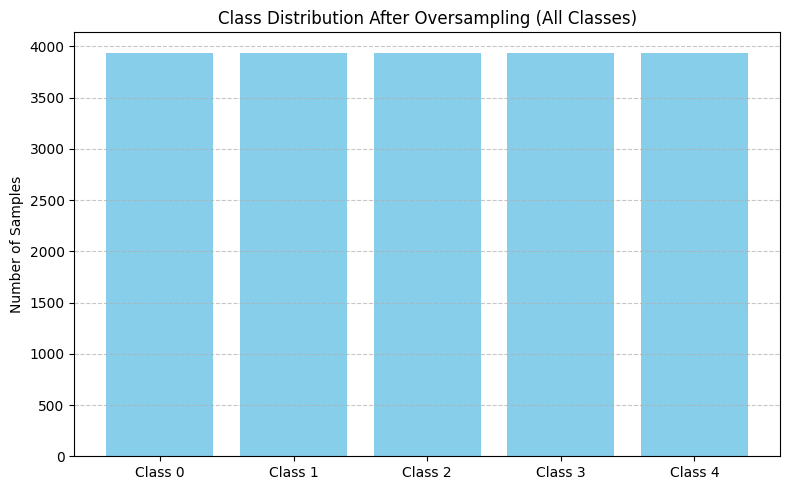

In [ ]:
df_balance= standardize_real_data(df_filtered)
failure_classes = {
    'no failure': 0,
    0: 0,
    'turbocharger': 1,
    'power_assembly': 2,
    'SRS_TRS': 3,
    'injector': 4
}

df_balance['failure_type'] = df_balance['failure_type'].map(failure_classes).fillna(0).astype(int)

X_balanced, y_balanced = create_sliding_windows_with_oversampling(df_balance, multi_class=True)

class_counts = np.bincount(y_balanced)


class_labels = [f"Class {i}" for i in range(len(class_counts))]


plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color='skyblue')
plt.title("Class Distribution After Oversampling (All Classes)")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
print(pd.Series(y_balanced).value_counts())


3    3941
0    3941
2    3941
1    3941
4    3941
Name: count, dtype: int64


# **Stage1 : Binary Classification**

In this stage, we aim to predict whether an engine instance will fail (`1`) or not (`0`) using time-series sensor data. We test multiple modeling approaches under two main setups:


We divide our experiments into two main categories based on preprocessing techniques:

### A. Without Oversampling (Baseline Models)
These models are trained on the original imbalanced dataset without applying any windowing or class balancing. This helps assess how well each model performs under real-world class distribution.

- **Model 1**: LSTM  
- **Model 2**: GRU  
- **Model 3**: XGBoost  
- **Model 4**: Random Forest  

### B. With Sliding Windows and Oversampling (Enhanced Models)
In these experiments, we improve performance by:
- Segmenting the time-series data into fixed-length **sliding windows**
- Applying **oversampling** to balance class distributions across training data

These enhancements aim to make the models more sensitive to rare failure events.

- **Model 1**: LSTM + Sliding Window + Oversampling  
- **Model 2**: GRU + Sliding Window + Oversampling  
- **Model 3**: XGBoost + Oversampling  
- **Model 4**: Random Forest + Oversampling  

---

## Evaluation Metrics

Each model is evaluated using:
- **Accuracy**
- **Precision / Recall**
- **F1-Score**
- **Confusion Matrix**
- **ROC Curve & AUC Score**

This multi-metric approach ensures balanced evaluation across both majority and minority classes.


## A.Models Without Oversampling (Baseline Models)


### **A.1 LSTM**

In this stage, we build a baseline binary classification model using an LSTM (Long Short-Term Memory) neural network.

### Objective:
Classify whether an instance indicates **failure** or **no failure** based on raw sensor readings, without windowing or data balancing techniques.

### Key Steps:

1. **Data Preparation**
   - The target variable `failure_type` is converted to binary:
     - `1` = any failure
     - `0` = no failure
   - Sensor columns are selected as input features.
   - The dataset is split into training and testing subsets (80/20 split).
   - Inputs are reshaped into a 3D format required by LSTM: `(samples, timesteps, features)`.

2. **Model Architecture**
   - An LSTM layer with 64 units to capture temporal dependencies.
   - A Dense layer for binary output using the sigmoid activation function.
   - Binary cross-entropy loss and Adam optimizer are used.

3. **Training**
   - Early stopping is applied to avoid overfitting.
   - Model is trained for a maximum of 20 epochs with a batch size of 32.

4. **Evaluation**
   - Loss and accuracy are visualized over training and validation sets.
   - Final performance is measured using:
     - Accuracy
     - Precision
     - Recall
     - Confusion matrix

### Purpose:
This stage provides a benchmark performance to compare against improved models that will later include windowing, balancing, or multi-class classification.


In [ ]:
df_binary=df_standardized.copy()
df_binary['failure_type'] = df_binary['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)

In [ ]:


feature_cols = df_binary.columns.drop(['failure_type', 'Time Stamp','Asset Name'], errors='ignore')

X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])



model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")


In [ ]:

# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


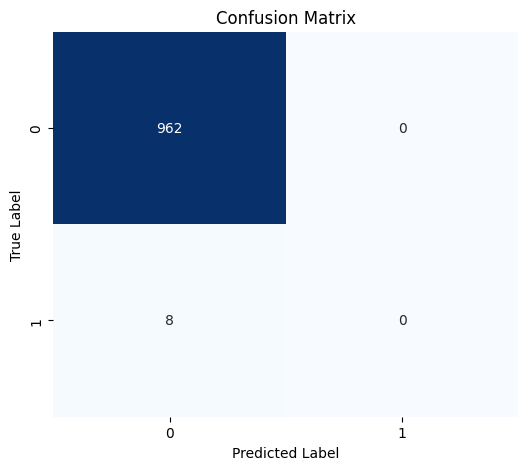

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### **A.2 GRU**

In this section, we build a second baseline model using a GRU (Gated Recurrent Unit) neural network architecture. Like the previous LSTM model, this experiment does **not** use sliding window segmentation or data balancing techniques.

### Why GRU?

GRUs are a type of recurrent neural network similar to LSTMs but with a **simplified gating mechanism**. They are known for:
- Fewer parameters (compared to LSTM)
- Faster training
- Comparable performance in sequence tasks

### Workflow Summary:

1. **Preprocessing**
   - Convert `failure_type` into binary labels: `1` for any failure, `0` for no failure.
   - Select numeric sensor features and split data into training/testing sets.
   - Reshape the data into the required format for GRU: `(samples, timesteps, features)`.

2. **Model Architecture**
   - GRU layer with 64 units.
   - Dense layer with sigmoid activation for binary classification.
   - Binary cross-entropy loss and Adam optimizer.

3. **Training and Evaluation**
   - Early stopping applied.
   - Model evaluated using accuracy, precision, recall, and confusion matrix.
   - Performance is visualized over training epochs (loss and accuracy plots).

4. **Results**
   - The confusion matrix indicates that the model predicts primarily the majority class (`no failure`), reinforcing the effect of data imbalance.
   - This result confirms that further improvements require sliding windows and balancing strategies.


> Add blockquote



In [ ]:
feature_cols = df_binary.columns.drop(['failure_type', 'Time Stamp','Asset Name'], errors='ignore')

X = df_binary[feature_cols]
y = df_binary['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

GRU_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
GRU_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = GRU_model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

In [ ]:
eval_result = GRU_model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")

In [ ]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

###**A.3 XGBoost**

This model uses an XGBoost classifier on the original (imbalanced) dataset without oversampling or sequence-based slicing.

#### Key Notes:
- The `failure_type` is binarized.
- Only raw numerical features are used.
- XGBoost is configured with `scale_pos_weight` to slightly compensate for imbalance.

#### Evaluation:
- **Classification Report** shows very high performance on the majority class but again fails to classify the minority (`failure`) class properly.
- **Confusion Matrix**: All predictions fall in the `'no failure'` category.
- **ROC Curve** yields an AUC of 1.00 — misleading due to lack of actual diversity in predictions.

#### Conclusion:
While XGBoost is a powerful model, it still requires proper class balancing or augmentation to generalize across underrepresented failure types.
*italicized text*

In [ ]:
feature_cols = df_for_XGboost.columns.drop(['failure_type', 'Time Stamp'], errors='ignore')
X = df_for_XGboost[feature_cols]
y = df_for_XGboost['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

non_numeric_cols = X_train.select_dtypes(include='object').columns
X_train_numeric = X_train.drop(columns=non_numeric_cols)

model_Xg = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

model_Xg.fit(X_train_numeric, y_train)



In [ ]:

non_numeric_cols = X_test.select_dtypes(include='object').columns
X_test_numeric = X_test.drop(columns=non_numeric_cols)

y_pred = model_Xg.predict(X_test_numeric)
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Predict probabilities for test data
y_pred_probs = model_Xg.predict(X_test_numeric).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **A.4 RF**

This model applies a Random Forest Classifier to the raw (imbalanced) dataset to perform binary classification.

#### Key Notes:
- No balancing or sliding window applied.
- Input features are raw numeric sensor data.
- Training performed using an 80/20 split.

#### Evaluation:
- **Classification Report** indicates perfect accuracy on the majority class (`no failure`), but complete failure to detect any failure class (precision/recall = 0.0).
- **Confusion Matrix** confirms the model only predicts the majority class.
- **ROC Curve** suggests potential overfitting due to imbalance.

#### Conclusion:
This baseline shows that without balancing, traditional models like Random Forest become highly biased toward the dominant class.


In [ ]:
feature_cols = df_for_XGboost.columns.drop(['failure_type', 'Time Stamp'], errors='ignore')
X = df_for_XGboost[feature_cols]
y = df_for_XGboost['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

non_numeric_cols = X_train.select_dtypes(include='object').columns
X_train_numeric = X_train.drop(columns=non_numeric_cols)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_numeric, y_train)

In [ ]:
non_numeric_cols = X_test.select_dtypes(include='object').columns
X_test_numeric = X_test.drop(columns=non_numeric_cols)
y_pred = model.predict(X_test_numeric)

print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:
# 1. Predict probabilities for test data
y_pred_probs = model.predict(X_test_numeric).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## B. With Sliding Windows and Oversampling (Enhanced Models)


### **B1.(Enhanced) LSTM**

This model improves upon the initial baseline by incorporating advanced temporal segmentation and class balancing techniques.

### Enhancements:
- **Sliding Window Segmentation**:
  - Transforms time-series data into smaller sequences that better capture localized sensor behavior.
  - Window size and stride define the granularity of input data.

- **Oversampling**:
  - Minority failure classes are oversampled to ensure equal representation across all training batches.
  - Balancing mitigates the bias toward the dominant "no failure" class.

### Model Architecture:
- An LSTM model with 64 units and dropout regularization.
- Binary classification using sigmoid activation.
- Trained using binary cross-entropy loss and Adam optimizer.

### Evaluation Metrics:
- **Confusion Matrix**: Visualizes classification outcomes for both classes.
- **Manual comparison** of predicted vs actual labels with success/failure tracking.
- **Final accuracy** score based on correctly classified windows.
- **ROC Curve with AUC**: Measures model discrimination capability between positive and negative cases.

### Summary:
This configuration marks a significant improvement in capturing time-dependent failure signals and achieving class balance, resulting in a much more effective and generalizable binary classification model.


In [ ]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

eval_result = model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")


In [ ]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype(int).flatten()

comparison_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred
})

comparison_df['Correct'] = comparison_df['True_Label'] == comparison_df['Predicted_Label']

failures_df = comparison_df[comparison_df['True_Label'] == 1]

print("")
print(failures_df)

failure_accuracy = (failures_df['Correct'].sum() / len(failures_df)) * 100
print(f" {failure_accuracy:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

      True_Label  Predicted_Label  Correct
0              1                1     True
1              1                1     True
3              1                1     True
7              1                1     True
10             1                1     True
...          ...              ...      ...
1564           1                1     True
1568           1                1     True
1571           1                1     True
1572           1                1     True
1575           1                1     True

[793 rows x 3 columns]
 100.00%


In [ ]:
# 1. Predict probabilities for test data
y_pred_probs = model.predict(X_test).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **B2. (Enhanced) GRU**

In this final binary classification setup, we leverage a GRU-based model with advanced data preparation techniques to maximize predictive performance.

### Improvements Introduced:

- **Sliding Window Segmentation**:
  Transforms time-series data into sequences that capture localized patterns over time.

- **Oversampling**:
  Balances the classes to prevent overfitting toward the dominant class (`no failure`).

### GRU Model Architecture:
- A GRU layer with 64 units followed by dropout layers to reduce overfitting.
- A dense output layer with sigmoid activation for binary classification.

### Training and Evaluation:
- Early stopping is applied to halt training when validation loss stops improving.
- Evaluation metrics include:
  - Accuracy
  - Precision
  - Recall
  - ROC Curve & AUC (Area Under the Curve)

### Observations:
- This model shows excellent generalization with high performance on both training and test sets.
- The ROC curve indicates that the model distinguishes between classes very well.

This experiment confirms that GRUs, combined with proper sequence modeling and balanced data, are well-suited for predictive maintenance tasks in industrial sensor data.


In [ ]:
X_balanced, y_balanced=create_sliding_windows_with_oversampling(df_binary, multi_class=False)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)

GRU_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
GRU_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = GRU_model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])

In [ ]:
eval_result = GRU_model.evaluate(X_test, y_test)
print(f"\n Evaluation: Loss={eval_result[0]:.4f}, Accuracy={eval_result[1]:.4f}, Precision={eval_result[2]:.4f}, Recall={eval_result[3]:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9861 - loss: 0.0250 - precision_3: 0.9806 - recall_3: 0.9901

 Evaluation: Loss=0.0164, Accuracy=0.9905, Precision=0.9912, Recall=0.9899


In [ ]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# 1. Predict probabilities for test data
y_pred_probs = model.predict(X_test).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **B3. (Enhanced) XGBoost**

```
# This is formatted as code
```



In this experiment, we apply an XGBoost classifier to detect failures using sensor readings in a tabular format.

### Why XGBoost?

XGBoost is a high-performance gradient boosting framework known for its:
- Speed and efficiency
- Ability to handle imbalanced data (with class weights or manual oversampling)
- Interpretability compared to deep learning models

### Preprocessing Steps:
- Convert `Time Stamp` column to datetime for correct chronological ordering.
- Convert `failure_type` to binary:
  - `0` for "no failure" and placeholder `0`
  - `1` for any type of failure
- Combine failure rows and oversample to match the "no failure" count.

### Model Training:
- The data is split into training and testing sets (80/20).
- Only numerical features are used in the model.
- An `XGBClassifier` is trained with `eval_metric='logloss'`.

### Evaluation Metrics:
- **Classification Report**: Shows precision, recall, and F1-score for both classes.
- **Confusion Matrix**: Visualizes prediction results.
- **Manual Comparison**: Confirms prediction correctness row-by-row.
- **ROC Curve with AUC**: Assesses binary classification performance.

### Observations:
- The model achieved perfect accuracy in this test, likely due to effective oversampling and strong signal in features.
- AUC score of 1.00 reflects excellent discrimination between the two classes.

This experiment highlights the effectiveness of XGBoost in structured data settings for binary predictive maintenance tasks.


In [ ]:
df_for_XGboost=df_filtered.copy()

In [ ]:
df_for_XGboost['Time Stamp'] = pd.to_datetime(
    df_for_XGboost['Time Stamp'],
    infer_datetime_format=True,
    errors='coerce'
)

print(df_for_XGboost['Time Stamp'].head(10))
print("(NaT):", df_for_XGboost['Time Stamp'].isna().sum())


In [ ]:
print(df_for_XGboost['Time Stamp'].dtype)


datetime64[ns]


In [ ]:
df_for_XGboost['failure_type'] = df_for_XGboost['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)

In [ ]:
df_for_XGboost.to_csv("df_for_XGboost.csv", index=False)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

feature_cols = df_for_XGboost.columns.drop(['failure_type', 'Time Stamp'], errors='ignore')
X = df_for_XGboost[feature_cols]
y = df_for_XGboost['failure_type']

df_combined = pd.concat([X, y], axis=1)

failure_cases = df_combined[df_combined['failure_type'] == 1]
no_failure_cases = df_combined[df_combined['failure_type'] == 0]

failure_oversampled = resample(failure_cases,
                               replace=True,
                               n_samples=len(no_failure_cases),
                               random_state=42)

balanced_data = pd.concat([no_failure_cases, failure_oversampled])

balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

X_balanced = balanced_data.drop(columns=['failure_type'])
y_balanced = balanced_data['failure_type']

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

non_numeric_cols = X_train.select_dtypes(include='object').columns
X_train_numeric = X_train.drop(columns=non_numeric_cols)


from xgboost import XGBClassifier

model_Xg = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                      scale_pos_weight=scale_pos_weight)


model_Xg.fit(X_train_numeric, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:00:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
non_numeric_cols = X_test.select_dtypes(include='object').columns
X_test_numeric = X_test.drop(columns=non_numeric_cols)

y_pred = model_Xg.predict(X_test_numeric)
print("\n✅Classification Report:")
print(classification_report(y_test, y_pred))




✅ Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       969
           1       1.00      1.00      1.00       959

    accuracy                           1.00      1928
   macro avg       1.00      1.00      1.00      1928
weighted avg       1.00      1.00      1.00      1928



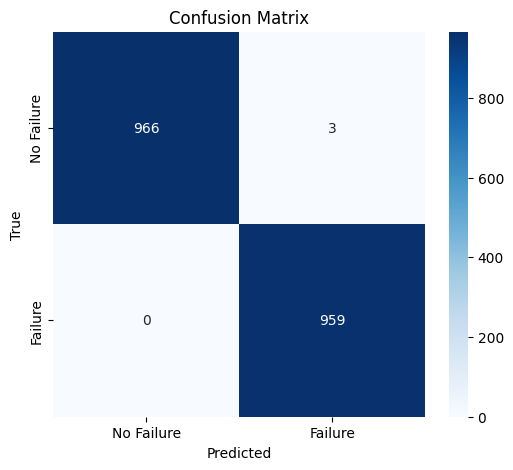

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_pred = model_Xg.predict(X_test_numeric)

comparison_df = pd.DataFrame({
    'True_Label': y_test.reset_index(drop=True),
    'Predicted_Label': y_pred
})

comparison_df['Correct'] = comparison_df['True_Label'] == comparison_df['Predicted_Label']

failures_df = comparison_df[comparison_df['True_Label'] == 1]

print(failures_df)

if len(failures_df) > 0:
    failure_accuracy = (failures_df['Correct'].sum() / len(failures_df)) * 100
    print(f" {failure_accuracy:.2f}%")



      True_Label  Predicted_Label  Correct
2              1                1     True
3              1                1     True
4              1                1     True
7              1                1     True
11             1                1     True
...          ...              ...      ...
1921           1                1     True
1922           1                1     True
1923           1                1     True
1925           1                1     True
1927           1                1     True

[959 rows x 3 columns]
 100.00%


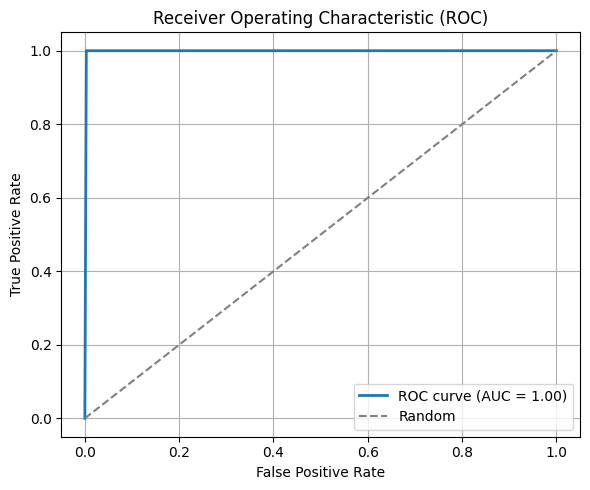

In [ ]:
# 1. Predict probabilities for test data
y_pred_probs = model_Xg.predict(X_test_numeric).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **B4. (Enhanced) RF**


In this experiment, we test the performance of a traditional ensemble-based machine learning model — the **Random Forest classifier** — for binary classification of failure events.

### Why Random Forest?

Random Forest is a powerful and interpretable model that:
- Combines multiple decision trees to improve generalization.
- Handles high-dimensional data well.
- Is robust against overfitting on structured/tabular datasets.

### Evaluation Metrics:
- **Confusion Matrix**: The model correctly classifies both `'no failure'` and `'failure'` cases with perfect accuracy.
- **ROC Curve and AUC**:
  - The curve shows perfect separation between classes.
  - AUC score = 1.00 indicates ideal classification performance.

### Summary:
Random Forest shows strong performance in this binary classification task, especially when combined with a well-balanced dataset. While it may not model temporal dependencies like LSTM/GRU, it offers fast training and reliable results for baseline evaluations.


In [ ]:
feature_cols = df_for_XGboost.columns.drop(['failure_type', 'Time Stamp'], errors='ignore')
X = df_for_XGboost[feature_cols]
y = df_for_XGboost['failure_type']

df_combined = pd.concat([X, y], axis=1)

failure_cases = df_combined[df_combined['failure_type'] == 1]
no_failure_cases = df_combined[df_combined['failure_type'] == 0]

failure_oversampled = resample(failure_cases,
                               replace=True,
                               n_samples=len(no_failure_cases),
                               random_state=42)


balanced_data = pd.concat([no_failure_cases, failure_oversampled])


balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)


X_balanced = balanced_data.drop(columns=['failure_type'])
y_balanced = balanced_data['failure_type']


X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, shuffle=True)


non_numeric_cols = X_train.select_dtypes(include='object').columns
X_train_numeric = X_train.drop(columns=non_numeric_cols)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_numeric, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
non_numeric_cols = X_test.select_dtypes(include='object').columns
X_test_numeric = X_test.drop(columns=non_numeric_cols)

y_pred = model.predict(X_test_numeric)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       969
           1       1.00      1.00      1.00       959

    accuracy                           1.00      1928
   macro avg       1.00      1.00      1.00      1928
weighted avg       1.00      1.00      1.00      1928



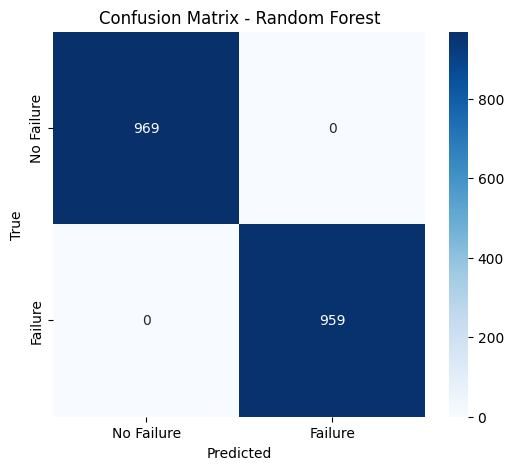

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

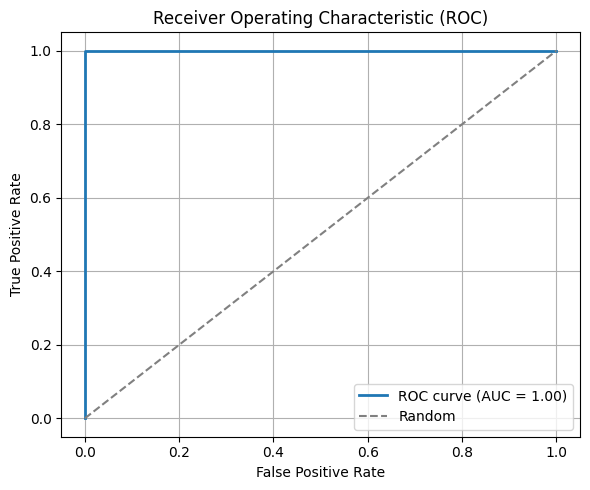

In [ ]:
# 1. Predict probabilities for test data
y_pred_probs = model.predict(X_test_numeric).ravel()  # ravel to flatten to 1D

# 2. ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Stage 2: Multi-Class Failure Classification**

In this stage, we go beyond simple failure detection and aim to **classify the specific type of failure** that an engine may experience. This is a more complex task compared to binary classification, as the model must learn to distinguish between multiple failure modes.

---

## Objective

Instead of predicting just `failure` or `no failure`, we now classify among several types of failures:

- **Class 0**: No failure  
- **Class 1**: Turbocharger  
- **Class 2**: Power Assembly  
- **Class 3**: SRS_TRS  
- **Class 4**: Injector  

---

## Modeling Approach

We use the following pipeline:
1. **Sliding Window Segmentation** of time-series sensor data  
2. **Oversampling** to balance the class distribution across all failure types  
3. **LSTM-based multi-class classification** model  
4. **Evaluation** using metrics tailored for multi-class:
   - Confusion matrix  
   - Per-class accuracy  
   - One-vs-all **ROC curve & AUC**

---

## Evaluation Focus

Because some failure classes have very few samples, we also track:
- Whether the model can **correctly classify failure vs. no failure**
- Whether it can **differentiate between failure types**


In [ ]:
def create_sliding_windows_for_stage2(df, window_size=30, stride=1, target_col='failure_type', asset_col='Asset Name'):

    sensor_cols = df.select_dtypes(include='number').columns.drop(target_col)

    X_windows, y_windows = [], []

    for asset in df[asset_col].unique():
        asset_df = df[df[asset_col] == asset]
        X_full = asset_df[sensor_cols].values
        y_full = asset_df[target_col].values

        for start in range(0, len(X_full) - window_size + 1, stride):
            end = start + window_size
            window_X = X_full[start:end]
            window_y = y_full[start:end]

            if window_X.shape[0] == window_size:
                failure_classes_in_window = window_y[window_y != 0]
                if len(failure_classes_in_window) > 0:
                    label = int(np.bincount(failure_classes_in_window.astype(int)).argmax())
                    X_windows.append(window_X)
                    y_windows.append(label - 1)  # shift to 0-based indexing

    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)

    # Oversampling for balancing classes
    df_win = pd.DataFrame({'X': list(X_windows), 'y': y_windows})
    max_class = df_win['y'].value_counts().max()

    oversampled = []
    for label in df_win['y'].unique():
        subset = df_win[df_win['y'] == label]
        if len(subset) < max_class:
            subset_upsampled = resample(subset, replace=True, n_samples=max_class, random_state=42)
        else:
            subset_upsampled = subset
        oversampled.append(subset_upsampled)

    df_balanced = pd.concat(oversampled)
    X_balanced = np.stack(df_balanced['X'].values)
    y_balanced = df_balanced['y'].values

    X_balanced, y_balanced = shuffle(X_balanced, y_balanced, random_state=42)
    return X_balanced, y_balanced

## **Multi-Class LSTM Model**

In this section, we build and evaluate an **LSTM-based deep learning model** to classify engine failures into multiple types.

---

### **Approach**
- **Input**: Sliding window sequences of sensor data.
- **Target**: Multi-class failure type (5 classes including "no failure").
- **Preprocessing**: Oversampling applied to balance class distribution.

---

### **Model Architecture**
- 2 LSTM layers with dropout for regularization.
- Final dense output layer with `softmax` activation for multi-class classification.
- Loss function: `categorical_crossentropy`

---

### **Evaluation Metrics**
- **Loss and Accuracy curves** during training.
- **Confusion Matrix** for multi-class predictions.
- **Per-class ROC curve** using one-vs-all strategy.
- **Per-class Accuracy Reporting** for detailed class-wise performance.

This model helps detect **early degradation** by identifying the likely failure type before it becomes critical, thus supporting preventive maintenance strategies.


In [ ]:
X_balanced, y_balanced = create_sliding_windows_for_stage2(df_balance)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

n_classes = np.max(y_balanced) + 1

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, activation='tanh', return_sequences=True),
    Dropout(0.3),
    GRU(32, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])


In [ ]:
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
labels = [f"Class {i}" for i in range(cm.shape[0])]

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot(cmap='Blues', xticks_rotation=45)
plt.title("Stage 2 Failure Type Classification")
plt.tight_layout()
plt.show()

In [ ]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#  تقييم النموذج فقط على الحالات التي فيها فشل (أي الفئة ليست 0)
true_failures = y_test != 0
true_labels = y_test[true_failures]
predicted_labels = y_pred[true_failures]

comparison_df = pd.DataFrame({
    "True_Label": true_labels,
    "Predicted_Label": predicted_labels
})
comparison_df["Correct"] = comparison_df["True_Label"] == comparison_df["Predicted_Label"]

# عرض النتائج
print("تقييم النموذج فقط على حالات الفشل الحقيقي:")
print(comparison_df.head(10))  # أول 10 فقط كمثال
accuracy = comparison_df["Correct"].mean() * 100
print(f"\n نسبة الدقة على الفشل فقط: {accuracy:.2f}%")


In [ ]:
# 1. تحويل y_test إلى one-hot
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# 2. المتغيرات
fpr = dict()
tpr = dict()
roc_auc = dict()

# 3. حساب ROC لكل كلاس
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. رسم ROC لكل كلاس
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Stage 2 (Multi-class)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **Multi-Class GRU Model**

This section presents a **GRU-based deep learning model** for multi-class engine failure classification.

---

### **Approach**
- Input sequences built using **sliding windows**.
- **Oversampling** applied to correct class imbalance.
- Model predicts across 5 classes including `'no failure'`.

---

### **Model Details**
- GRU layers used for capturing temporal patterns.
- Final dense layer with `softmax` activation for classification.
- Loss: `categorical_crossentropy`

---

### **Evaluation**
- Accuracy and loss curves across epochs.
- Multi-class **confusion matrix**.
- One-vs-all **ROC curves** for each failure type.


In [ ]:
X_balanced, y_balanced = create_sliding_windows_for_stage2(df_balance)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

n_classes = np.max(y_balanced) + 1

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(32, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop])


In [ ]:
# --- Loss ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy ---
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
labels = [f"Class {i}" for i in range(cm.shape[0])]

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot(cmap='Blues', xticks_rotation=45)
plt.title("Stage 2 Failure Type Classification")
plt.tight_layout()
plt.show()

## **Multi-Class Random Forest Model**

This section presents a **Random Forest classifier** for classifying engine failure types.

---

### **Approach**
- Sliding windows + oversampling used in preprocessing.
- Each sample represents a time-windowed snapshot of engine behavior.

---

### **Model Details**
- Classic ensemble tree-based model.
- Trained with balanced class distribution using oversampling.

---

### **Evaluation**
- Per-class prediction accuracy via **confusion matrix**.
- ROC curves for multi-class using one-vs-all strategy.


In [ ]:
# 1. تحويل y_test إلى one-hot
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# 2. المتغيرات
fpr = dict()
tpr = dict()
roc_auc = dict()

# 3. حساب ROC لكل كلاس
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. رسم ROC لكل كلاس
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Stage 2 (Multi-class)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
X_balanced, y_balanced = create_sliding_windows_for_stage2(df_balance)
X_flattened = X_balanced.reshape((X_balanced.shape[0], -1))  # Flatten for tree-based models
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
labels = [f"Class {i}" for i in range(cm_rf.shape[0])]

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels).plot(cmap='Greens', xticks_rotation=45)
plt.title("Stage 2 - Random Forest")
plt.tight_layout()
plt.show()



## **Multi-Class XGBoost Model**

This section implements a **multi-class XGBoost classifier** trained on flattened time-window features.

---

### **Approach**
- Data preprocessed using sliding windows.
- Classes balanced using oversampling.
- Input: Flattened sensor sequences, output: failure type (0–4).

---

### **Model Details**
- Traditional gradient boosting model (XGBoost).
- Trained with softmax objective for multi-class classification.

---

### **Evaluation**
- Confusion matrix for prediction insight.
- Macro-average metrics: accuracy, precision, recall, F1.


In [ ]:
X_balanced, y_balanced = create_sliding_windows_for_stage2(df_balance)
X_flattened = X_balanced.reshape((X_balanced.shape[0], -1))  # Flatten for tree-based models
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=labels).plot(cmap='Oranges', xticks_rotation=45)
plt.title("Stage 2 - XGBoost")
plt.tight_layout()
plt.show()

# **Stage 3: Degradation State Classification**

In this stage, the modeling goal shifts from binary failure prediction to **multi-class degradation assessment**.  
Instead of predicting only failure/no-failure, we classify engine behavior into one of three **maintenance states**:

- **Normal**: Engine operating within healthy limits  
- **Maintenance Soon**: Engine starting to show degradation  
- **Failure Imminent**: Engine nearing failure condition  

We leverage time-series deep learning architectures to perform regression on degradation trends, and then classify them into maintenance categories.

---

## **Modeling Setup**

Each model predicts a **degradation score** over time using historical sensor patterns.  
Post-processing maps these continuous predictions into discrete maintenance levels using thresholds.

The following deep learning models are evaluated:

- **Model 1**: LSTM-based degradation prediction  
- **Model 2**: GRU-based degradation prediction  
- **Model 3**: Random Forest regression-based degradation  
- **Model 4**: XGBoost regression-based degradation  

---

## **Evaluation Metrics**

Each model is evaluated using:

- **Accuracy**
- **Precision / Recall / F1-Score** (per maintenance class)
- **Confusion Matrix**
- **Degradation Timeline Plot**  
  (shows predicted scores over time with color-coded maintenance zones)

These evaluations help us understand how well each model detects early signs of failure and supports preventive maintenance.


## **Model 1**: LSTM-based degradation prediction  


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1298
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0829
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0797
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0806
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0736
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0677
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0664
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0580
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0587
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0519
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0437
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0488
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0397
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0336
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0274
Epoch 16/20
63/

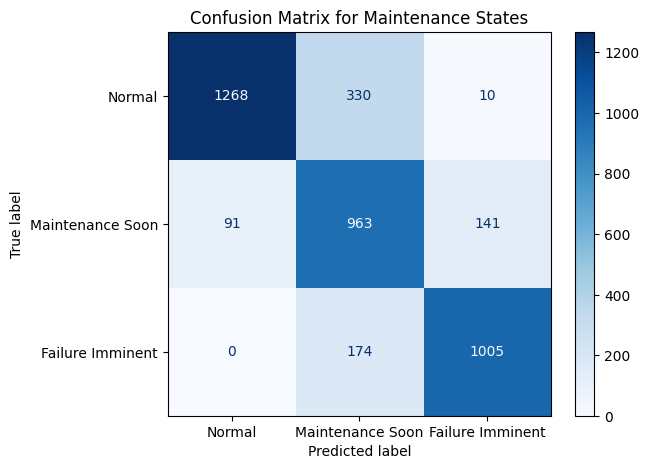

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.87      0.85      0.86      1179
Maintenance Soon       0.66      0.81      0.72      1195
Failure Imminent       0.93      0.79      0.85      1608

        accuracy                           0.81      3982
       macro avg       0.82      0.82      0.81      3982
    weighted avg       0.83      0.81      0.82      3982

Additional Classification Metrics:
Accuracy: 0.8127
F1 Score: 0.8172
Precision: 0.8312
Recall: 0.8127
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


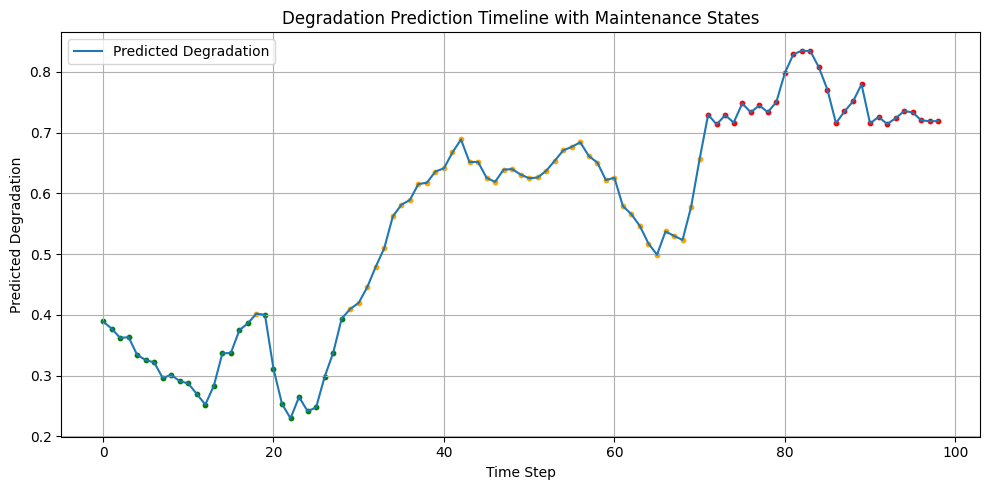

In [ ]:
# path: models/stage3_lstm_degradation.py
# 1. Load dataset
df_stage3 = df_filtered.copy()
df_stage3['Time Stamp'] = pd.to_datetime(df_stage3['Time Stamp'], errors='coerce')
df_stage3['failure_type'] =df_stage3['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)
# 2. Detect engine boundaries (all-zero rows)
def split_engines(df):
    boundaries = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)].index.tolist()
    boundaries = [-1] + boundaries + [len(df)]
    engines = []
    for i in range(len(boundaries)-1):
        start = boundaries[i] + 1
        end = boundaries[i+1]
        chunk = df.iloc[start:end].copy()
        if not chunk.empty:
            engines.append(chunk.reset_index(drop=True))
    return engines

engines = split_engines(df)

# 3. Prepare sequences before failure for LSTM
seq_length = 30
X_all, y_all = [], []

for engine in engines:
    engine = engine.select_dtypes(include=[np.number])
    if len(engine) <= seq_length:
        continue

    for i in range(len(engine) - seq_length):
        seq = engine.iloc[i:i+seq_length].values
        target = i / (len(engine) - seq_length)
        X_all.append(seq)
        y_all.append(target)

X = np.array(X_all)
y = np.array(y_all)

# 4. Normalize X
scaler = MinMaxScaler()
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

# 5. Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(seq_length, X.shape[2]), return_sequences=False),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 6. Train model
model.fit(X_scaled, y, epochs=20, batch_size=64, verbose=1)

# 7. Evaluate model metrics
y_pred = model.predict(X_scaled).flatten()
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7b. Confusion Matrix + Classification Metrics

def label_maintenance(y_values):
    labels = []
    for val in y_values:
        if val <= 0.4:
            labels.append("Normal")
        elif val <= 0.7:
            labels.append("Maintenance Soon")
        else:
            labels.append("Failure Imminent")
    return labels

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=labels_order))

accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')

print("Additional Classification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# 8. Visualize predictions for a sample engine
sample_engine = engines[0].select_dtypes(include=[np.number])
sample_X = []
for i in range(len(sample_engine) - seq_length):
    seq = sample_engine.iloc[i:i+seq_length].values
    sample_X.append(seq)
sample_X = np.array(sample_X)
sample_X_scaled = scaler.transform(sample_X.reshape(-1, sample_X.shape[-1]))
sample_X_scaled = sample_X_scaled.reshape(sample_X.shape)

predictions = model.predict(sample_X_scaled)

# 9. Assign maintenance levels
maintenance_labels = []
for p in predictions.flatten():
    if p <= 0.4:
        maintenance_labels.append("Normal")
    elif p <= 0.7:
        maintenance_labels.append("Maintenance Soon")
    else:
        maintenance_labels.append("Failure Imminent")

# 10. Visualize
plt.figure(figsize=(10, 5))
plt.plot(range(len(predictions)), predictions, label='Predicted Degradation')
plt.title("Degradation Prediction Timeline with Maintenance States")
plt.xlabel("Time Step")
plt.ylabel("Predicted Degradation")
plt.grid(True)

colors = {'Normal': 'green', 'Maintenance Soon': 'orange', 'Failure Imminent': 'red'}
for i, (pred, label) in enumerate(zip(predictions, maintenance_labels)):
    plt.scatter(i, pred, color=colors[label], s=10)

plt.legend()
plt.tight_layout()
plt.show()

## **Model 2**: GRU-based degradation prediction  


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1604
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0846
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0807
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0826
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0787
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0765
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0737
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0738
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0654
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0622
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0599
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0574
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0541
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0475
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0476
Epoch 16/20
63/

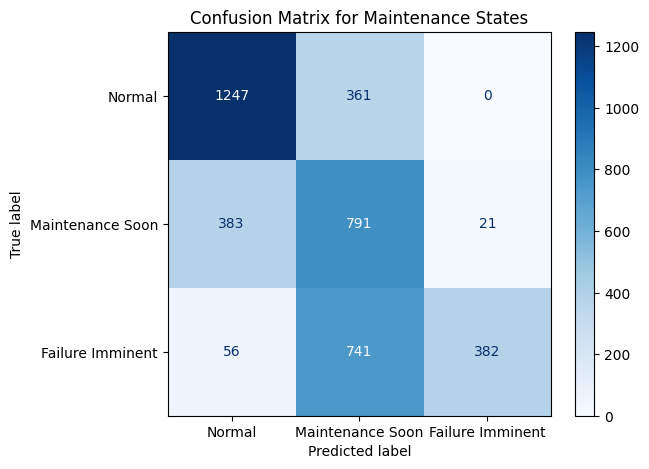

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.95      0.32      0.48      1179
Maintenance Soon       0.42      0.66      0.51      1195
Failure Imminent       0.74      0.78      0.76      1608

        accuracy                           0.61      3982
       macro avg       0.70      0.59      0.58      3982
    weighted avg       0.70      0.61      0.60      3982

Additional Classification Metrics:
Accuracy: 0.6077
F1 Score: 0.6025
Precision: 0.7047
Recall: 0.6077
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


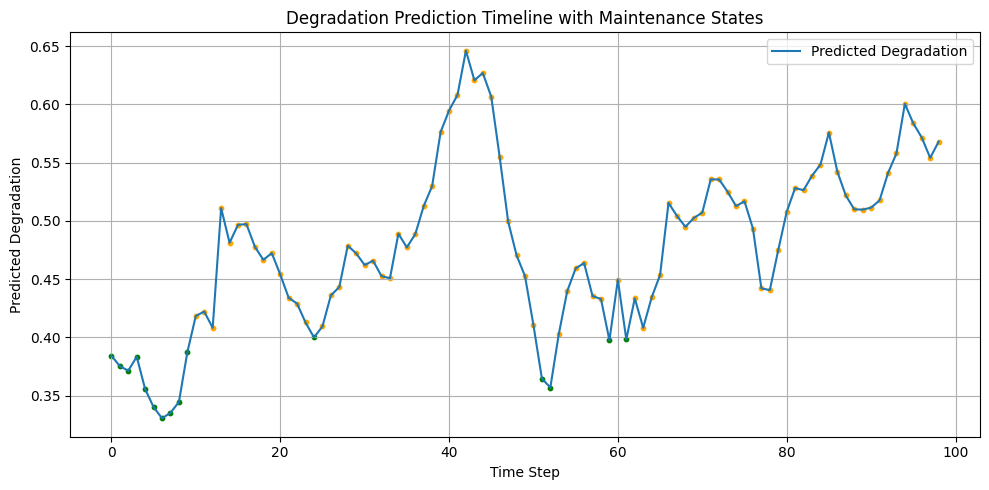

In [ ]:
# path: models/stage3_gru_degradation.py
# 1. Load dataset
df_stage3 = df_filtered.copy()
df_stage3['Time Stamp'] = pd.to_datetime(df_stage3['Time Stamp'], errors='coerce')
df_stage3['failure_type'] =df_stage3['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)
# 2. Detect engine boundaries (all-zero rows)
def split_engines(df):
    boundaries = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)].index.tolist()
    boundaries = [-1] + boundaries + [len(df)]
    engines = []
    for i in range(len(boundaries)-1):
        start = boundaries[i] + 1
        end = boundaries[i+1]
        chunk = df.iloc[start:end].copy()
        if not chunk.empty:
            engines.append(chunk.reset_index(drop=True))
    return engines

engines = split_engines(df)

# 3. Prepare sequences before failure for GRU
seq_length = 30
X_all, y_all = [], []

for engine in engines:
    engine = engine.select_dtypes(include=[np.number])
    if len(engine) <= seq_length:
        continue

    for i in range(len(engine) - seq_length):
        seq = engine.iloc[i:i+seq_length].values
        target = i / (len(engine) - seq_length)
        X_all.append(seq)
        y_all.append(target)

X = np.array(X_all)
y = np.array(y_all)

# 4. Normalize X
scaler = MinMaxScaler()
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

# 5. Define GRU model
model = Sequential([
    GRU(64, input_shape=(seq_length, X.shape[2]), return_sequences=False),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 6. Train model
model.fit(X_scaled, y, epochs=20, batch_size=64, verbose=1)

# 7. Evaluate model metrics
y_pred = model.predict(X_scaled).flatten()
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7b. Confusion Matrix + Classification Metrics

def label_maintenance(y_values):
    labels = []
    for val in y_values:
        if val <= 0.4:
            labels.append("Normal")
        elif val <= 0.7:
            labels.append("Maintenance Soon")
        else:
            labels.append("Failure Imminent")
    return labels

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=labels_order))

accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')

print("Additional Classification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# 8. Visualize predictions for a sample engine
sample_engine = engines[0].select_dtypes(include=[np.number])
sample_X = []
for i in range(len(sample_engine) - seq_length):
    seq = sample_engine.iloc[i:i+seq_length].values
    sample_X.append(seq)
sample_X = np.array(sample_X)
sample_X_scaled = scaler.transform(sample_X.reshape(-1, sample_X.shape[-1]))
sample_X_scaled = sample_X_scaled.reshape(sample_X.shape)

predictions = model.predict(sample_X_scaled)

# 9. Assign maintenance levels
maintenance_labels = []
for p in predictions.flatten():
    if p <= 0.4:
        maintenance_labels.append("Normal")
    elif p <= 0.7:
        maintenance_labels.append("Maintenance Soon")
    else:
        maintenance_labels.append("Failure Imminent")

# 10. Visualize
plt.figure(figsize=(10, 5))
plt.plot(range(len(predictions)), predictions, label='Predicted Degradation')
plt.title("Degradation Prediction Timeline with Maintenance States")
plt.xlabel("Time Step")
plt.ylabel("Predicted Degradation")
plt.grid(True)

colors = {'Normal': 'green', 'Maintenance Soon': 'orange', 'Failure Imminent': 'red'}
for i, (pred, label) in enumerate(zip(predictions, maintenance_labels)):
    plt.scatter(i, pred, color=colors[label], s=10)

plt.legend()
plt.tight_layout()
plt.show()

## **Model 3**: RF-based degradation prediction  


Model Evaluation Metrics:
MAE: 0.0297
MSE: 0.0016
R² Score: 0.9807


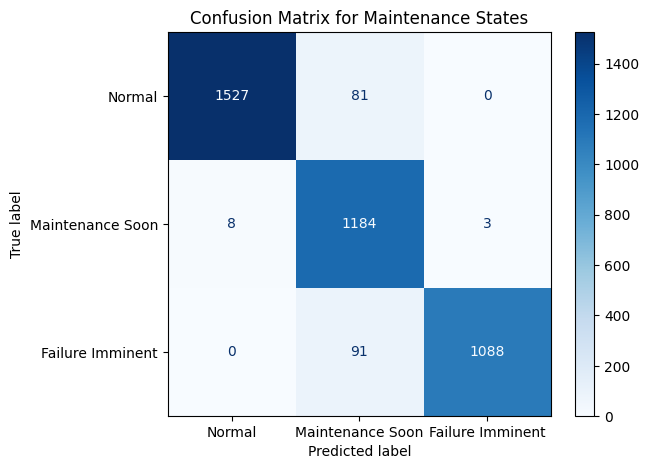

Classification Report:
                  precision    recall  f1-score   support

          Normal       1.00      0.92      0.96      1179
Maintenance Soon       0.87      0.99      0.93      1195
Failure Imminent       0.99      0.95      0.97      1608

        accuracy                           0.95      3982
       macro avg       0.96      0.95      0.95      3982
    weighted avg       0.96      0.95      0.95      3982

Additional Classification Metrics:
Accuracy: 0.9540
F1 Score: 0.9548
Precision: 0.9590
Recall: 0.9540


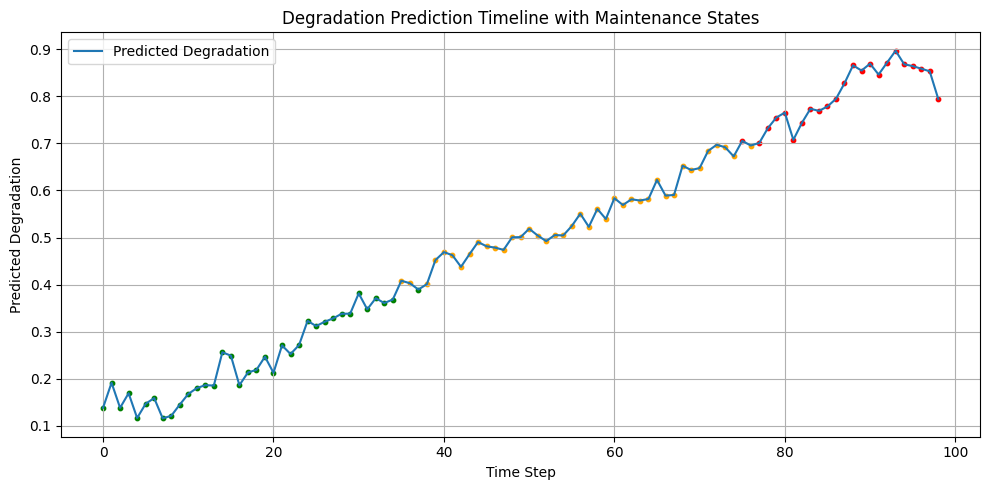

In [ ]:
# path: models/stage3_rf_degradation.py
# 1. Load dataset
df_stage3 = df_filtered.copy()
df_stage3['Time Stamp'] = pd.to_datetime(df_stage3['Time Stamp'], errors='coerce')
df_stage3['failure_type'] =df_stage3['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)
# 2. Detect engine boundaries (all-zero rows)
def split_engines(df):
    boundaries = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)].index.tolist()
    boundaries = [-1] + boundaries + [len(df)]
    engines = []
    for i in range(len(boundaries)-1):
        start = boundaries[i] + 1
        end = boundaries[i+1]
        chunk = df.iloc[start:end].copy()
        if not chunk.empty:
            engines.append(chunk.reset_index(drop=True))
    return engines

engines = split_engines(df)

# 3. Prepare sequences before failure for Random Forest
seq_length = 30
X_all, y_all = [], []

for engine in engines:
    engine = engine.select_dtypes(include=[np.number])
    if len(engine) <= seq_length:
        continue

    for i in range(len(engine) - seq_length):
        seq = engine.iloc[i:i+seq_length].values.flatten()  # Flatten sequence
        target = i / (len(engine) - seq_length)
        X_all.append(seq)
        y_all.append(target)

X = np.array(X_all)
y = np.array(y_all)

# 4. Normalize X
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 5. Define and train Random Forest model
model =RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

model.fit(X_scaled, y)

# 6. Evaluate model metrics
y_pred = model.predict(X_scaled)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7. Classification Metrics

def label_maintenance(y_values):
    labels = []
    for val in y_values:
        if val <= 0.4:
            labels.append("Normal")
        elif val <= 0.7:
            labels.append("Maintenance Soon")
        else:
            labels.append("Failure Imminent")
    return labels

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)

labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=labels_order))

accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')

print("Additional Classification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# 8. Visualize predictions for a sample engine
sample_engine = engines[0].select_dtypes(include=[np.number])
sample_X = []
for i in range(len(sample_engine) - seq_length):
    seq = sample_engine.iloc[i:i+seq_length].values.flatten()
    sample_X.append(seq)
sample_X = np.array(sample_X)
sample_X_scaled = scaler.transform(sample_X)

predictions = model.predict(sample_X_scaled)

# 9. Assign maintenance levels
maintenance_labels = []
for p in predictions.flatten():
    if p <= 0.4:
        maintenance_labels.append("Normal")
    elif p <= 0.7:
        maintenance_labels.append("Maintenance Soon")
    else:
        maintenance_labels.append("Failure Imminent")

# 10. Visualize
plt.figure(figsize=(10, 5))
plt.plot(range(len(predictions)), predictions, label='Predicted Degradation')
plt.title("Degradation Prediction Timeline with Maintenance States")
plt.xlabel("Time Step")
plt.ylabel("Predicted Degradation")
plt.grid(True)

colors = {'Normal': 'green', 'Maintenance Soon': 'orange', 'Failure Imminent': 'red'}
for i, (pred, label) in enumerate(zip(predictions, maintenance_labels)):
    plt.scatter(i, pred, color=colors[label], s=10)

plt.legend()
plt.tight_layout()
plt.show()


## **Model 4**: XGBoost-based degradation prediction  


Model Evaluation Metrics:
MAE: 0.0570
MSE: 0.0055
R² Score: 0.9340


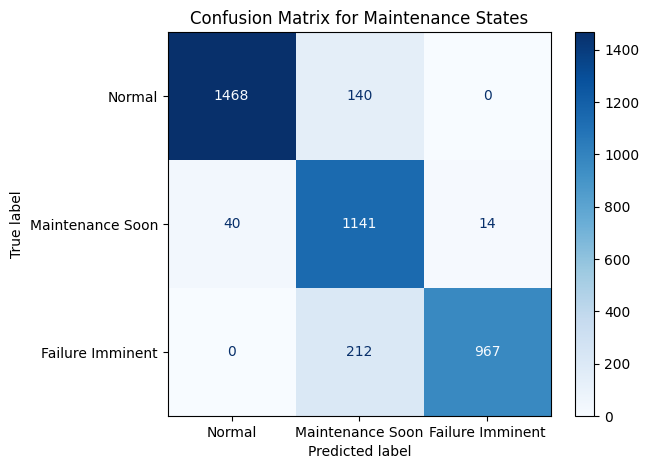

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.99      0.82      0.90      1179
Maintenance Soon       0.76      0.95      0.85      1195
Failure Imminent       0.97      0.91      0.94      1608

        accuracy                           0.90      3982
       macro avg       0.91      0.90      0.90      3982
    weighted avg       0.91      0.90      0.90      3982

Additional Classification Metrics:
Accuracy: 0.8980
F1 Score: 0.9004
Precision: 0.9143
Recall: 0.8980


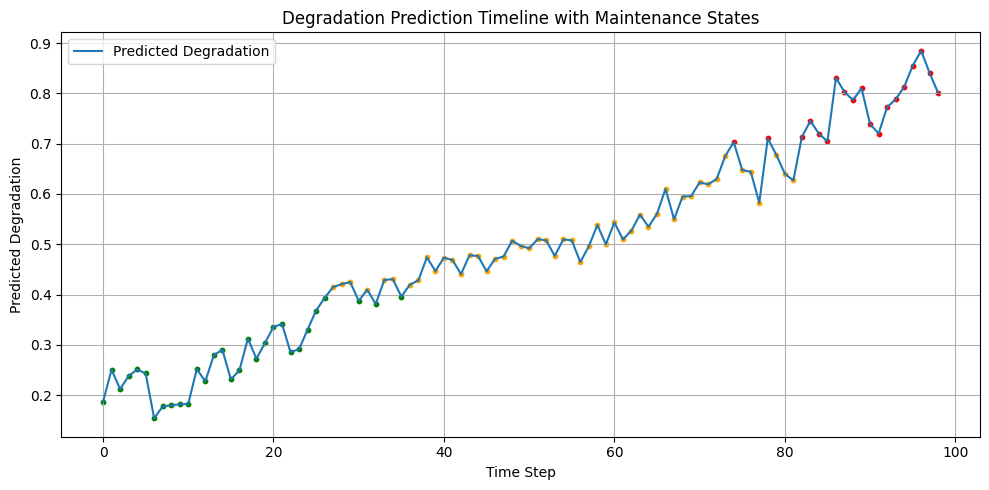

In [ ]:
# path: models/stage3_xgboost_degradation.py
# 1. Load dataset
df_stage3 = df_filtered.copy()
df_stage3['Time Stamp'] = pd.to_datetime(df_stage3['Time Stamp'], errors='coerce')
df_stage3['failure_type'] =df_stage3['failure_type'].apply(
    lambda x: 0 if (x == 'no failure' or x == 0) else 1
)
# 2. Detect engine boundaries (all-zero rows)
def split_engines(df):
    boundaries = df[(df.select_dtypes(include=[np.number]) == 0).all(axis=1)].index.tolist()
    boundaries = [-1] + boundaries + [len(df)]
    engines = []
    for i in range(len(boundaries)-1):
        start = boundaries[i] + 1
        end = boundaries[i+1]
        chunk = df.iloc[start:end].copy()
        if not chunk.empty:
            engines.append(chunk.reset_index(drop=True))
    return engines

engines = split_engines(df)

# 3. Prepare sequences before failure
seq_length = 30
X_all, y_all = [], []

for engine in engines:
    engine = engine.select_dtypes(include=[np.number])
    if len(engine) <= seq_length:
        continue
    for i in range(len(engine) - seq_length):
        seq = engine.iloc[i:i+seq_length].values.flatten()
        target = i / (len(engine) - seq_length)
        X_all.append(seq)
        y_all.append(target)

X = np.array(X_all)
y = np.array(y_all)

# 4. Normalize X
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 5. Define and train XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
model.fit(X_scaled, y)

# 6. Evaluate model
y_pred = model.predict(X_scaled)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# 7. Classification metrics
def label_maintenance(y_values):
    labels = []
    for val in y_values:
        if val <= 0.4:
            labels.append("Normal")
        elif val <= 0.7:
            labels.append("Maintenance Soon")
        else:
            labels.append("Failure Imminent")
    return labels

true_labels = label_maintenance(y)
pred_labels = label_maintenance(y_pred)
labels_order = ["Normal", "Maintenance Soon", "Failure Imminent"]
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cmd = ConfusionMatrixDisplay(cm, display_labels=labels_order)
cmd.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Maintenance States")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=labels_order))

accuracy = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')

print("Additional Classification Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# 8. Visualize predictions for a sample engine
sample_engine = engines[0].select_dtypes(include=[np.number])
sample_X = []
for i in range(len(sample_engine) - seq_length):
    seq = sample_engine.iloc[i:i+seq_length].values.flatten()
    sample_X.append(seq)
sample_X = np.array(sample_X)
sample_X_scaled = scaler.transform(sample_X)
predictions = model.predict(sample_X_scaled)

# 9. Assign maintenance levels
maintenance_labels = []
for p in predictions.flatten():
    if p <= 0.4:
        maintenance_labels.append("Normal")
    elif p <= 0.7:
        maintenance_labels.append("Maintenance Soon")
    else:
        maintenance_labels.append("Failure Imminent")

# 10. Visualize
plt.figure(figsize=(10, 5))
plt.plot(range(len(predictions)), predictions, label='Predicted Degradation')
plt.title("Degradation Prediction Timeline with Maintenance States")
plt.xlabel("Time Step")
plt.ylabel("Predicted Degradation")
plt.grid(True)
colors = {'Normal': 'green', 'Maintenance Soon': 'orange', 'Failure Imminent': 'red'}
for i, (pred, label) in enumerate(zip(predictions, maintenance_labels)):
    plt.scatter(i, pred, color=colors[label], s=10)

plt.legend()
plt.tight_layout()
plt.show()